In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway,mannwhitneyu
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

In [3]:
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]

In [5]:
cell_proportions=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/bp_res_mid_lvl_ct_updated_ct_fraction_batch_3.csv")
cell_proportions

,dcc_filename,tumor,Tcells_reg,Bcells,Fibroblasts,NKcells,Tcells_CD8,Tcells_CD4,Macrophages_Monocytes,Mast_cells,...,Endothelial_cells,Roi,Segment,Sample,NACT_status,Annotation_cell,Segment_geomx,Patient,Site,tls_status
0,DSP-1001660016604-A-A02.dcc,0.745048,0.005637,0.013962,0.016963,0.038538,0.022655,0.020136,0.076275,0.005074,...,0.027749,001,stroma,S130_iOme,post,CD8_Iba1,tsi,S130,Omentum,NaN
1,DSP-1001660016604-A-A04.dcc,0.736724,0.005899,0.012362,0.026534,0.039378,0.022420,0.020560,0.074997,0.004222,...,0.029101,002,stroma,S130_iOme,post,CD8_CD11_Iba1,tsi,S130,Omentum,NaN
2,DSP-1001660016604-A-A05.dcc,0.752872,0.004808,0.012373,0.022766,0.041614,0.016138,0.023727,0.065603,0.004572,...,0.028374,002,tumor,S130_iOme,post,CD8_CD11_Iba1,tsi,S130,Omentum,NaN
3,DSP-1001660016604-A-A06.dcc,0.696677,0.004149,0.015270,0.033828,0.042673,0.026637,0.024694,0.088725,0.005369,...,0.030493,003,stroma,S130_iOme,post,CD4_CD8_CD11_Iba1,tsi,S130,Omentum,NaN
4,DSP-1001660016604-A-A07.dcc,0.751482,0.005152,0.013101,0.021124,0.042058,0.017583,0.022335,0.066053,0.004678,...,0.028555,003,tumor,S130_iOme,post,CD4_CD8_CD11_Iba1,tsi,S130,Omentum,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1144,DSP-1001660039918-D-H08.dcc,0.789346,0.004738,0.011969,0.021846,0.031720,0.021396,0.008878,0.061680,0.002980,...,0.018853,78,tumor,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN
1145,DSP-1001660039918-D-H09.dcc,0.579808,NaN,0.020152,0.096728,0.048274,0.047329,0.023439,0.106030,0.003534,...,0.037966,79,stroma,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN
1146,DSP-1001660039918-D-H10.dcc,0.818733,0.002757,0.010016,0.016281,0.028084,0.015355,0.011042,0.055040,0.002341,...,0.016717,79,tumor,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN
1147,DSP-1001660039918-D-H11.dcc,0.486454,0.001896,0.018246,0.112088,0.037951,0.060744,0.009077,0.199669,0.003054,...,0.027181,80,stroma,S378_iOme,post,CD4_CD8_CD11_Iba1,stroma,S378,Omentum,NaN


In [6]:
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv")
print(len(fibr_gene_expression_modified))
cell_proportions=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/bp_res_mid_lvl_ct_updated_ct_fraction_batch_3.csv")
fibr_gene_expression_modified = pd.merge(
    fibr_gene_expression_modified,
    cell_proportions,
    on="dcc_filename",
    how="inner"  # or "left", "right", "outer" depending on your needs
)
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b123","OS_quartile_b123"]],on="Patient", how="left")
#fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
#fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Sample","NACT_status"]],on="Sample", how="left")

1130


In [7]:
tumor_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/tumor_gene_expression_data_new_batch_three_merged_transposed.csv")
cell_proportions=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/bp_res_mid_lvl_ct_updated_ct_fraction_batch_3.csv")
tumor_gene_expression_modified = pd.merge(
    tumor_gene_expression_modified,
    cell_proportions,
    on="dcc_filename",
    how="inner"  # or "left", "right", "outer" depending on your needs
)
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
tumor_gene_expression_modified["Patient"]=tumor_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
tumor_gene_expression_modified=tumor_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b123","OS_quartile_b123"]],on="Patient", how="left")
#fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
#fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Sample","NACT_status"]],on="Sample", how="left")

In [8]:
tumor_gene_expression_modified.drop_duplicates(subset=["dcc_filename"], inplace=True)
tumor_gene_expression_modified

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Segment,Sample,NACT_status,Annotation_cell,Segment_geomx,Patient,Site,tls_status,PFS_quartile_b123,OS_quartile_b123
0,DSP-1001660016604-A-A02.dcc,4.839909,4.757586,4.192001,3.533371,4.210851,3.827944,5.502354,6.542906,3.633708,...,stroma,S130_iOme,post,CD8_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
1,DSP-1001660016604-A-A04.dcc,3.857972,4.656608,4.136695,3.850938,4.326377,4.527826,7.356994,6.906304,3.943593,...,stroma,S130_iOme,post,CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
2,DSP-1001660016604-A-A05.dcc,4.162980,4.730238,4.072939,3.120682,4.002466,4.191595,7.352134,6.893180,3.553284,...,tumor,S130_iOme,post,CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
3,DSP-1001660016604-A-A06.dcc,4.253177,4.403408,3.882272,3.600413,4.468903,5.693859,7.655464,5.575683,4.176585,...,stroma,S130_iOme,post,CD4_CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
4,DSP-1001660016604-A-A07.dcc,4.484327,4.768116,4.277912,3.373381,4.188810,4.255521,8.044070,6.676637,3.121102,...,tumor,S130_iOme,post,CD4_CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,DSP-1001660039918-D-H08.dcc,3.234637,5.358224,2.599185,2.685807,3.074142,3.635618,8.339449,7.659997,2.396117,...,tumor,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN,1.0,1.0
1931,DSP-1001660039918-D-H09.dcc,4.323569,4.430333,3.366736,3.543466,3.563736,4.478264,4.731133,6.188652,3.443477,...,stroma,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN,1.0,1.0
1932,DSP-1001660039918-D-H10.dcc,2.808929,5.486878,3.262124,3.036710,3.302485,3.083789,7.328345,8.145784,1.656094,...,tumor,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN,1.0,1.0
1933,DSP-1001660039918-D-H11.dcc,3.918540,4.814226,3.141019,2.820121,3.703439,5.078906,3.862867,5.897545,3.557068,...,stroma,S378_iOme,post,CD4_CD8_CD11_Iba1,stroma,S378,Omentum,NaN,1.0,1.0


In [9]:
fibr_gene_expression_modified.drop_duplicates(subset=["dcc_filename"], inplace=True)
fibr_gene_expression_modified

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Segment,Sample,NACT_status,Annotation_cell,Segment_geomx,Patient,Site,tls_status,PFS_quartile_b123,OS_quartile_b123
0,DSP-1001660016604-A-A02.dcc,1.775487,1.919513,1.756743,1.819186,-0.227464,2.133803,4.430383,1.907765,-0.289414,...,stroma,S130_iOme,post,CD8_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
1,DSP-1001660016604-A-A04.dcc,1.611748,1.755770,1.593038,1.655429,-0.227485,1.970136,5.556138,2.575339,-0.289414,...,stroma,S130_iOme,post,CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
2,DSP-1001660016604-A-A05.dcc,1.456122,1.600149,1.749836,1.106540,0.993677,1.814400,5.553614,2.162116,-0.289413,...,tumor,S130_iOme,post,CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
3,DSP-1001660016604-A-A06.dcc,1.301591,1.445616,2.047107,1.345285,-0.227470,2.940832,5.980615,1.433922,-0.289414,...,stroma,S130_iOme,post,CD4_CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
4,DSP-1001660016604-A-A07.dcc,1.444913,1.588940,1.873071,1.488621,-0.227453,2.250109,6.390664,2.024010,-0.289413,...,tumor,S130_iOme,post,CD4_CD8_CD11_Iba1,tsi,S130,Omentum,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1902,DSP-1001660039918-D-H08.dcc,0.779579,1.700681,0.878934,0.936072,-0.371043,1.203536,6.175561,1.983647,-0.288254,...,tumor,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN,1.0,1.0
1903,DSP-1001660039918-D-H09.dcc,1.361211,1.177415,1.243200,1.044651,0.500526,1.975167,3.280158,1.461945,-0.288245,...,stroma,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN,1.0,1.0
1904,DSP-1001660039918-D-H10.dcc,-0.718671,1.275135,1.086688,1.143747,-0.370780,1.411495,4.925540,2.245332,-0.288267,...,tumor,S378_iOme,post,CD4_CD8_CD11_Iba1,tsi,S378,Omentum,NaN,1.0,1.0
1905,DSP-1001660039918-D-H11.dcc,1.172670,1.294824,1.104917,0.752507,0.324075,2.124241,2.627741,1.389804,-0.288246,...,stroma,S378_iOme,post,CD4_CD8_CD11_Iba1,stroma,S378,Omentum,NaN,1.0,1.0


In [10]:
tumor_gene_expression_modified_post=tumor_gene_expression_modified[tumor_gene_expression_modified["NACT_status"]=="post"]
fibr_gene_expression_modified_post=fibr_gene_expression_modified[fibr_gene_expression_modified["NACT_status"]=="post"]

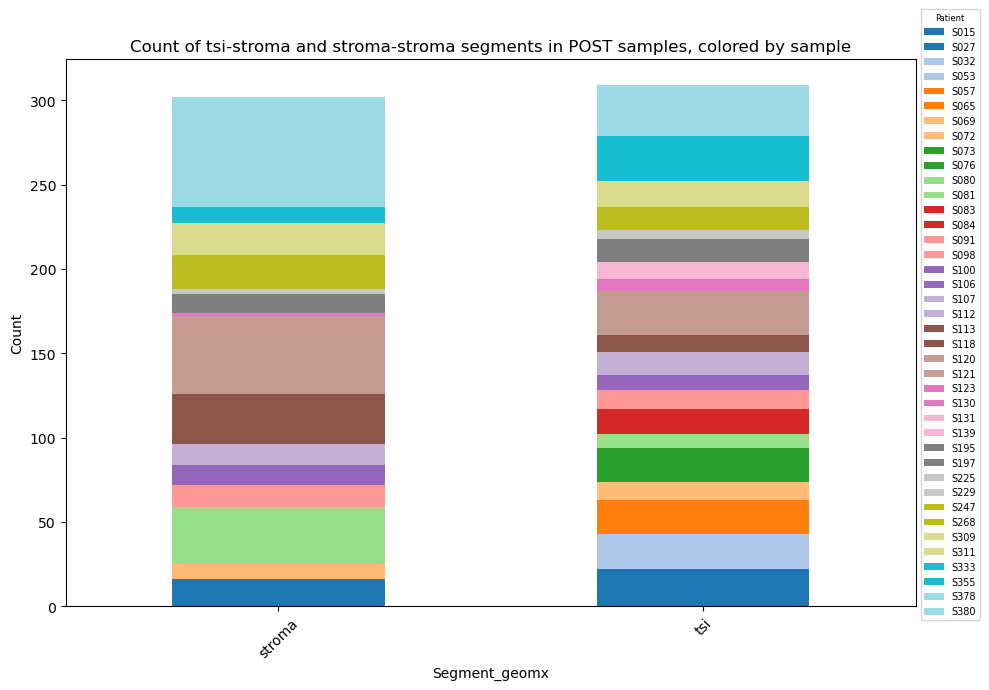

In [11]:
comb_counts = fibr_gene_expression_modified_post.groupby(
    ['Segment_geomx', 'Segment', 'Patient']
).size().reset_index(name='count')

# Step 2: Filter to only Segment_y == "stroma"
comb_counts = comb_counts[comb_counts["Segment"] == "stroma"]

# Step 3: Pivot the data so each Sample_y becomes a column
pivot_df = comb_counts.pivot_table(
    index='Segment_geomx',
    columns='Patient',
    values='count',
    fill_value=0
)

# Step 4: Plot as stacked bar chart
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    colormap='tab20'  # optional color palette
)

plt.title("Count of tsi-stroma and stroma-stroma segments in POST samples, colored by sample")
plt.xlabel("Segment_geomx")
plt.ylabel("Count")
plt.legend(title='Patient', bbox_to_anchor=(1.0, 1.1),fontsize=7, title_fontsize=6,loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


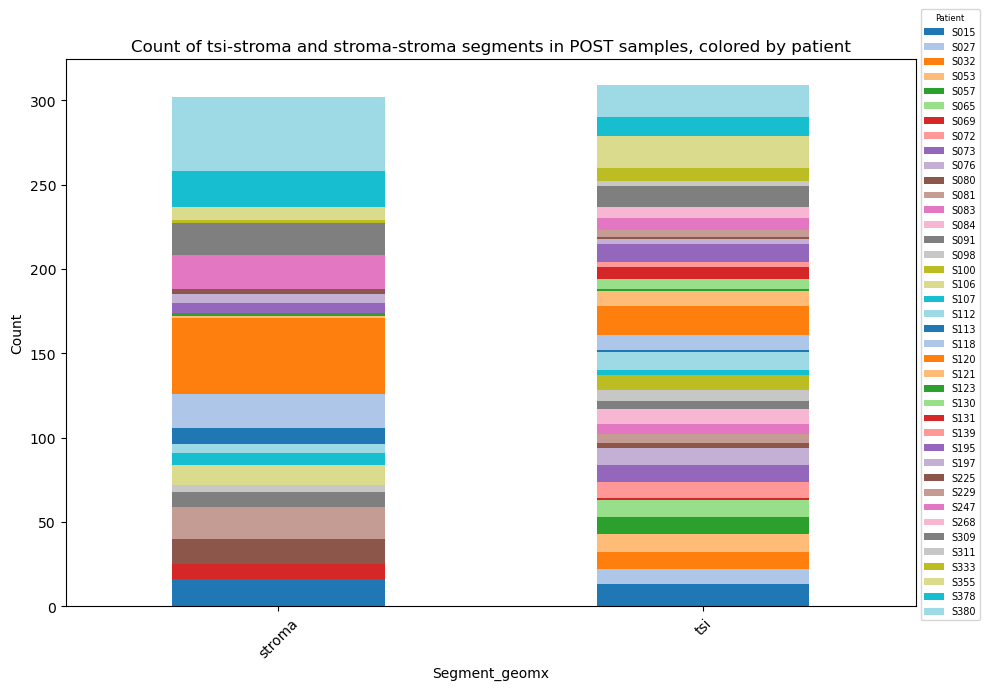

In [12]:
import matplotlib.pyplot as plt

# Get unique patients
patients = pivot_df.columns

# Choose a colormap and assign each patient a fixed color
cmap = plt.get_cmap('tab20')
colors = {patient: cmap(i % cmap.N) for i, patient in enumerate(patients)}

# Plot with consistent colors
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    color=[colors[patient] for patient in patients]  # fixed order and colors
)

plt.title("Count of tsi-stroma and stroma-stroma segments in POST samples, colored by patient")
plt.xlabel("Segment_geomx")
plt.ylabel("Count")
plt.legend(title='Patient', bbox_to_anchor=(1.0, 1.1), fontsize=7, title_fontsize=6, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
comb_counts = fibr_gene_expression_modified_post.groupby(
    ['Segment_geomx', 'Segment', 'Patient']
).size().reset_index(name='count')

# Step 2: Filter to only Segment_y == "stroma"
comb_counts = comb_counts[comb_counts["Segment"] == "stroma"]
comb_counts.sort_values(by='Patient',inplace=True)
comb_counts

,Segment_geomx,Segment,Patient,count
0,stroma,stroma,S015,16
24,tsi,stroma,S015,13
25,tsi,stroma,S027,9
26,tsi,stroma,S032,10
27,tsi,stroma,S053,11
...,...,...,...,...
60,tsi,stroma,S355,19
21,stroma,stroma,S378,21
61,tsi,stroma,S378,11
22,stroma,stroma,S380,44


In [14]:
# Count occurrences of each sample
sample_counts = comb_counts['Patient'].value_counts()

# Get only those with count == 1
single_occurrence_samples = sample_counts[sample_counts == 1].index

# Filter the original DataFrame
df_single_occurrence = comb_counts[
    comb_counts['Patient'].isin(single_occurrence_samples)
]

df_single_occurrence["Patient"].unique()

array(['S027', 'S032', 'S053', 'S057', 'S065', 'S072', 'S073', 'S076',
       'S083', 'S084', 'S100', 'S106', 'S130', 'S131', 'S139', 'S229',
       'S268', 'S311'], dtype=object)

In [15]:
fibr_gene_expression_modified_post_both= fibr_gene_expression_modified_post[
    ~fibr_gene_expression_modified_post['Patient'].isin(df_single_occurrence['Patient'].unique())
]

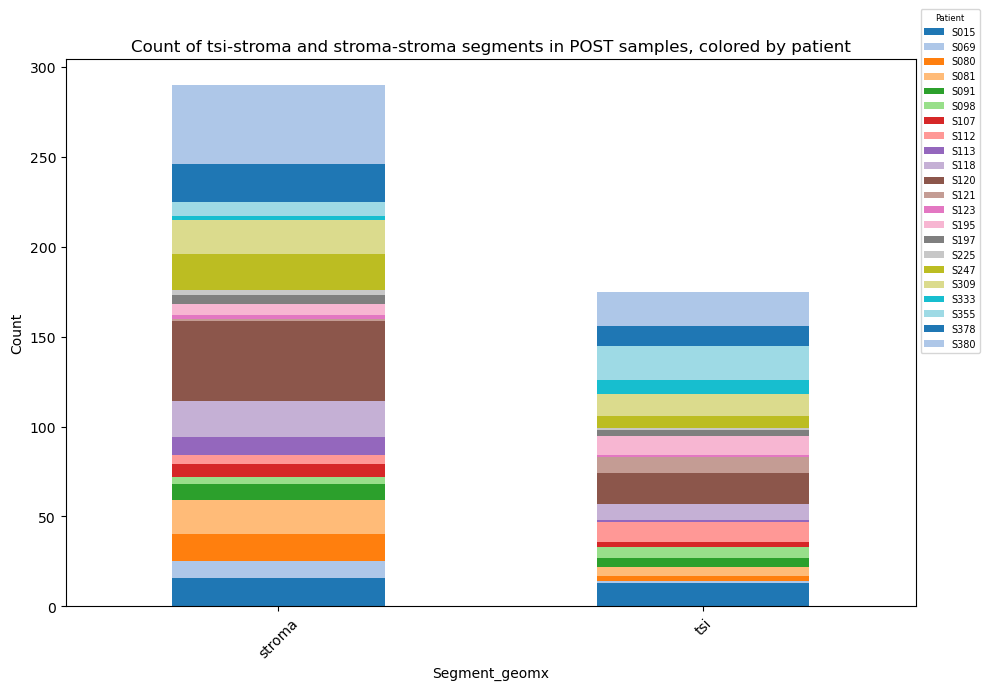

In [16]:
import matplotlib.pyplot as plt

comb_counts = fibr_gene_expression_modified_post_both.groupby(
    ['Segment_geomx', 'Segment', 'Patient']
).size().reset_index(name='count')

# Step 2: Filter to only Segment_y == "stroma"
comb_counts = comb_counts[comb_counts["Segment"] == "stroma"]

# Step 3: Pivot the data so each Sample_y becomes a column
pivot_df = comb_counts.pivot_table(
    index='Segment_geomx',
    columns='Patient',
    values='count',
    fill_value=0
)

# Get unique patients
patients = pivot_df.columns

# Choose a colormap and assign each patient a fixed color
cmap = plt.get_cmap('tab20')
colors = {patient: cmap(i % cmap.N) for i, patient in enumerate(patients)}

# Plot with consistent colors
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 7),
    color=[colors[patient] for patient in patients]  # fixed order and colors
)

plt.title("Count of tsi-stroma and stroma-stroma segments in POST samples, colored by patient")
plt.xlabel("Segment_geomx")
plt.ylabel("Count")
plt.legend(title='Patient', bbox_to_anchor=(1.0, 1.1), fontsize=7, title_fontsize=6, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
# Filter rows where Segment == "stroma"
stroma_subset = comb_counts[comb_counts['Segment'] == 'stroma']

# Count how many stroma rows have each Segment_geomx type (e.g., "tsi", "stroma")
geomx_counts = stroma_subset['Segment_geomx'].value_counts().reset_index()

geomx_counts.columns = ['Segment_geomx', 'count']

print(geomx_counts)

  Segment_geomx  count
0        stroma     22
1           tsi     22


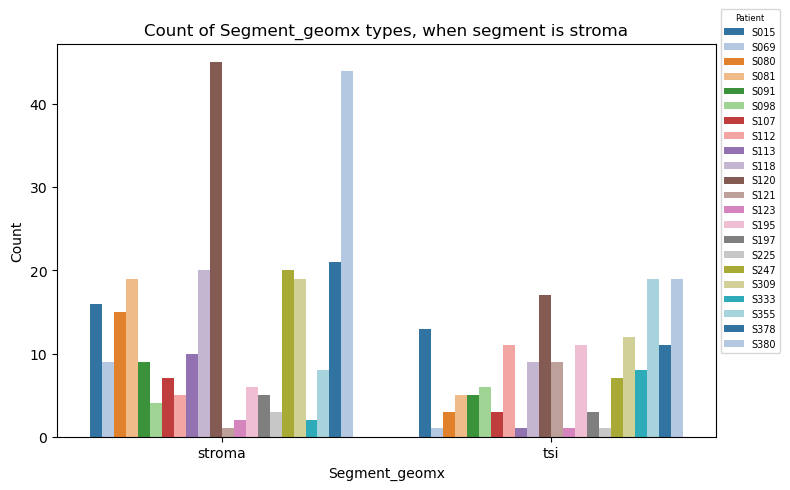

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=comb_counts, x='Segment_geomx', y='count', hue='Patient', palette='tab20')

plt.title("Count of Segment_geomx types, when segment is stroma")
plt.xlabel("Segment_geomx")
plt.ylabel("Count")
plt.legend(title='Patient', bbox_to_anchor=(1.0, 1.1), fontsize=7, title_fontsize=6, loc='upper left')
plt.tight_layout()
plt.show()


In [20]:
unique_combinations = fibr_gene_expression_modified_post_both[
    ['Patient', 'PFS_quartile_b123', 'OS_quartile_b123']
].drop_duplicates()

print(unique_combinations)

     Patient  PFS_quartile_b123  OS_quartile_b123
78      S121                1.0               1.0
332     S015                4.0               3.0
736     S098                3.0               4.0
752     S107                1.0               1.0
765     S197                2.0               2.0
776     S333                3.0               1.0
812     S080                4.0               4.0
833     S088                2.0               4.0
834     S069                2.0               2.0
940     S355                3.0               2.0
970     S091                4.0               4.0
973     S112                2.0               3.0
1132    S113                2.0               2.0
1139    S123                3.0               3.0
1510    S081                2.0               3.0
1518    S247                1.0               1.0
1573    S309                4.0               2.0
1621    S225                2.0               2.0
1629    S378                1.0               1.0


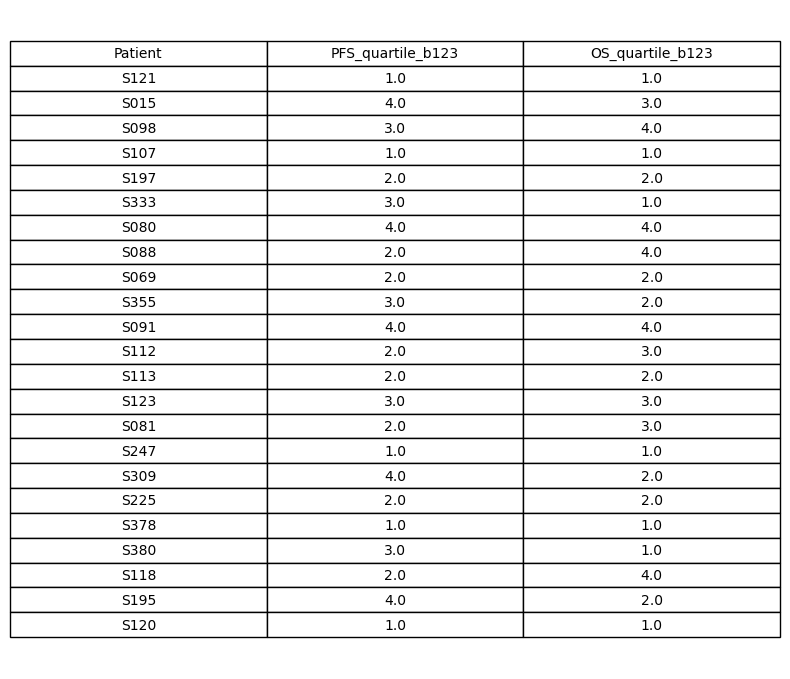

In [21]:
fig, ax = plt.subplots(figsize=(8, len(unique_combinations)*0.3 ))  # Adjust height

ax.axis('off')
tbl = ax.table(cellText=unique_combinations.values,
               colLabels=unique_combinations.columns,
               cellLoc='center',
               loc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.2)  # Adjust row height

plt.tight_layout()
plt.savefig('/Users/nikamikhailava/Desktop/batch_merged_new/unique_patient_combinations.png', dpi=300)
plt.show()

DGE analysis

In [23]:
geomx_data= pd.read_csv("//Volumes/h30492/farkkilab2/4_CellCycle_Nika/geomx/Data/Ada_transformed_data/geomx_count_data.csv")
geomx_data.drop(columns=["RCN1","RCN2","RCN3"], inplace=True)
geomx_data = geomx_data[geomx_data.columns.intersection(fibr_gene_expression_modified_post_both.columns)]

In [31]:

import pandas as pd
from scipy.stats import ttest_ind  # Add this import statement
from statsmodels.stats.multitest import multipletests
def volcano_analysis_with_comparison(data, group_column, comparison_labels, gene_columns):
    """
    Perform volcano analysis on RNAseq data for specified group comparisons.

    Parameters:
    - data (DataFrame): DataFrame containing RNAseq data.
    - group_column (str): Name of the column containing group labels.
    - comparison_labels (list of tuples): List of tuples specifying group label pairs for comparison.
    - gene_columns (slice): Slice object representing the range of columns containing gene information.

    Returns:
    - DataFrame: DataFrame with columns for fold change, p-value, q-value, -log10(p-value), and -log10(q-value)
                 for each specified group comparison.
    """
    result_df = pd.DataFrame()
    #gene_columns = geomx_data.columns
    print(gene_columns)
    for comparison in comparison_labels:
        group1, group2 = comparison
        print(group1, group2)
        # Calculate fold change
        group1_data = data[data[group_column] == group1].loc[:, gene_columns]
        group2_data = data[data[group_column] == group2].loc[:, gene_columns]
        #group1_data = group1_data.dropna(axis=1, how='all')
        #group2_data = group2_data.dropna(axis=1, how='all')
        avg_group1 = group1_data.mean()
        avg_group2 = group2_data.mean()
        fold_change = np.log2((group2_data.mean() + 1e-6) / (group1_data.mean() + 1e-6))
        # Calculate log2 fold change (log2 of fold-change)
        fold_change.name = f'fold-change_{group2}_over_{group1}'

        # Calculate p-value
        pvals = []
        for name in group1_data.columns:
            group1_val = group1_data[name].dropna()
            group2_val = group2_data[name].dropna()
            pvals.append(ttest_ind(group1_val, group2_val)[1])
        # Calculate q-value
        q_values = multipletests(pvals, method='fdr_bh')[1]

        # -log10 p-value
        log10pvals = [-np.log10(value) for value in pvals]

        # -log10 q-value
        log10qvals = [-np.log10(value) for value in q_values]

        # Add fold change, p-value, q-value, -log10(p-value), and -log10(q-value) to the result DataFrame
        result_df[f'fold-change'] = fold_change
        result_df[f'p-value'] = pvals
        result_df[f'q-value'] = q_values
        result_df[f'-log10_pvalue'] = log10pvals
        result_df[f'-log10_qvalue'] = log10qvals

    return result_df

In [32]:
df_results = {}  # dictionary to hold results

for patient in fibr_gene_expression_modified_post_both['Patient'].unique():
    # Filter data for current patient
    patient_data = fibr_gene_expression_modified_post_both[
        (fibr_gene_expression_modified_post_both["Patient"] == patient)  & (fibr_gene_expression_modified_post_both["Segment"] =="stroma")
    ]
    
    # Run the analysis
    result = volcano_analysis_with_comparison(
        patient_data,
        group_column='Segment_geomx',
        comparison_labels=[("stroma", "tsi")],
        gene_columns=geomx_data.columns
    )
    
    # Store result in dict with patient as key
    df_results[patient] = result


Index(['A2M', 'NAT2', 'ACADM', 'ACADS', 'ACAT1', 'ACVRL1', 'PSEN1', 'ADA',
       'SGCA', 'ADRB2',
       ...
       'PRKCG', 'TNFSF18', 'CCL23', 'WNT6', 'GLI1', 'NDUFA3', 'HAMP', 'ADH1B',
       'CCL3', 'CST2'],
      dtype='object', length=14850)
stroma tsi


/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Index(['A2M', 'NAT2', 'ACADM', 'ACADS', 'ACAT1', 'ACVRL1', 'PSEN1', 'ADA',
       'SGCA', 'ADRB2',
       ...
       'PRKCG', 'TNFSF18', 'CCL23', 'WNT6', 'GLI1', 'NDUFA3', 'HAMP', 'ADH1B',
       'CCL3', 'CST2'],
      dtype='object', length=14850)
stroma tsi


/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Index(['A2M', 'NAT2', 'ACADM', 'ACADS', 'ACAT1', 'ACVRL1', 'PSEN1', 'ADA',
       'SGCA', 'ADRB2',
       ...
       'PRKCG', 'TNFSF18', 'CCL23', 'WNT6', 'GLI1', 'NDUFA3', 'HAMP', 'ADH1B',
       'CCL3', 'CST2'],
      dtype='object', length=14850)
stroma tsi


...

/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Index(['A2M', 'NAT2', 'ACADM', 'ACADS', 'ACAT1', 'ACVRL1', 'PSEN1', 'ADA',
       'SGCA', 'ADRB2',
       ...
       'PRKCG', 'TNFSF18', 'CCL23', 'WNT6', 'GLI1', 'NDUFA3', 'HAMP', 'ADH1B',
       'CCL3', 'CST2'],
      dtype='object', length=14850)
stroma tsi


/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Index(['A2M', 'NAT2', 'ACADM', 'ACADS', 'ACAT1', 'ACVRL1', 'PSEN1', 'ADA',
       'SGCA', 'ADRB2',
       ...
       'PRKCG', 'TNFSF18', 'CCL23', 'WNT6', 'GLI1', 'NDUFA3', 'HAMP', 'ADH1B',
       'CCL3', 'CST2'],
      dtype='object', length=14850)
stroma tsi


/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/geomx/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [33]:
df_results

{'S121':          fold-change   p-value  q-value  -log10_pvalue  -log10_qvalue
 A2M     5.215982e-01  0.009135      NaN       2.039276            NaN
 NAT2    4.650698e-02  0.894412      NaN       0.048462            NaN
 ACADM  -2.603604e-01  0.107517      NaN       0.968524            NaN
 ACADS  -9.685899e-03  0.970697      NaN       0.012916            NaN
 ACAT1   4.493014e-02  0.744673      NaN       0.128034            NaN
 ...              ...       ...      ...            ...            ...
 NDUFA3  1.008473e-01  0.577507      NaN       0.238443            NaN
 HAMP    2.405703e-07  0.957658      NaN       0.018789            NaN
 ADH1B  -7.574532e-01  0.002885      NaN       2.539804            NaN
 CCL3   -8.478637e-01  0.213939      NaN       0.669711            NaN
 CST2   -2.162719e-01  0.269355      NaN       0.569674            NaN
 
 [14850 rows x 5 columns],
 'S015':         fold-change   p-value   q-value  -log10_pvalue  -log10_qvalue
 A2M        0.070990  0.385164  

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


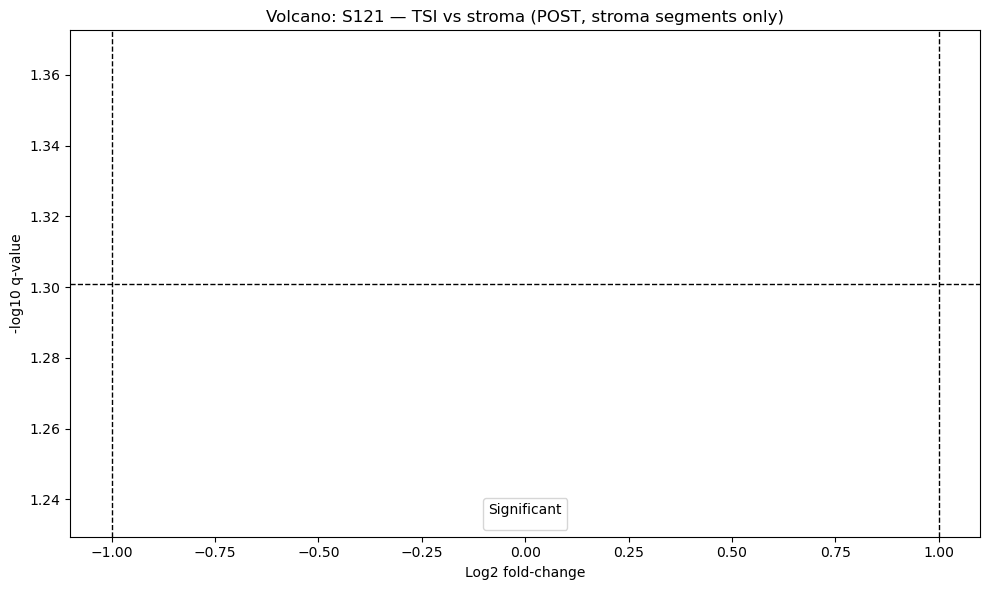

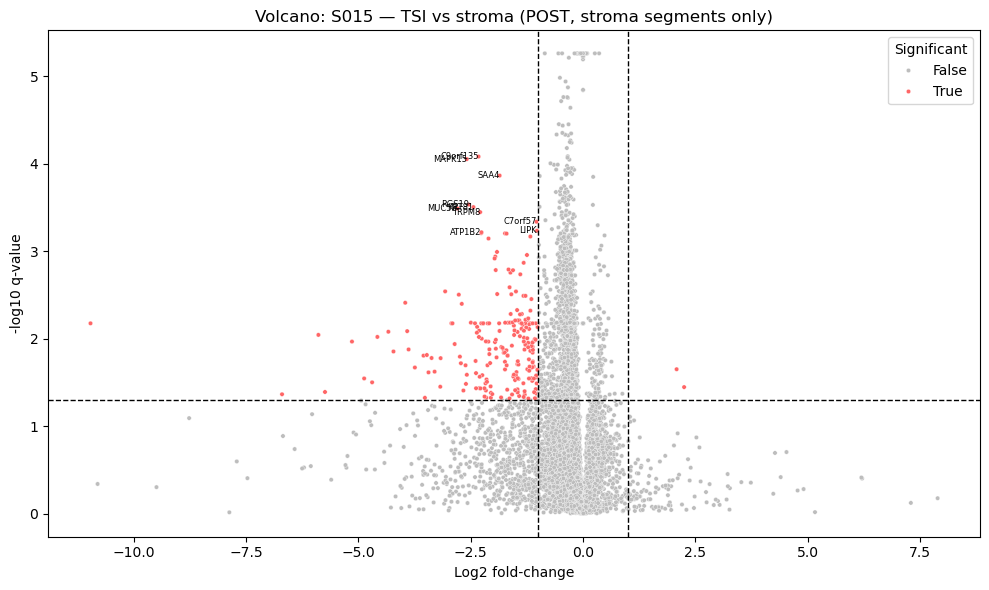

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


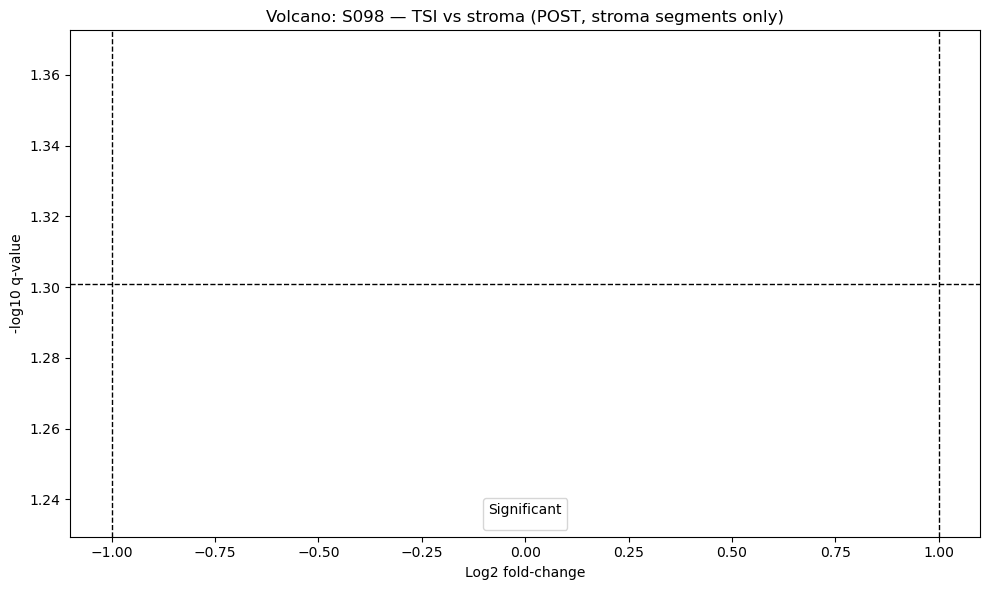

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


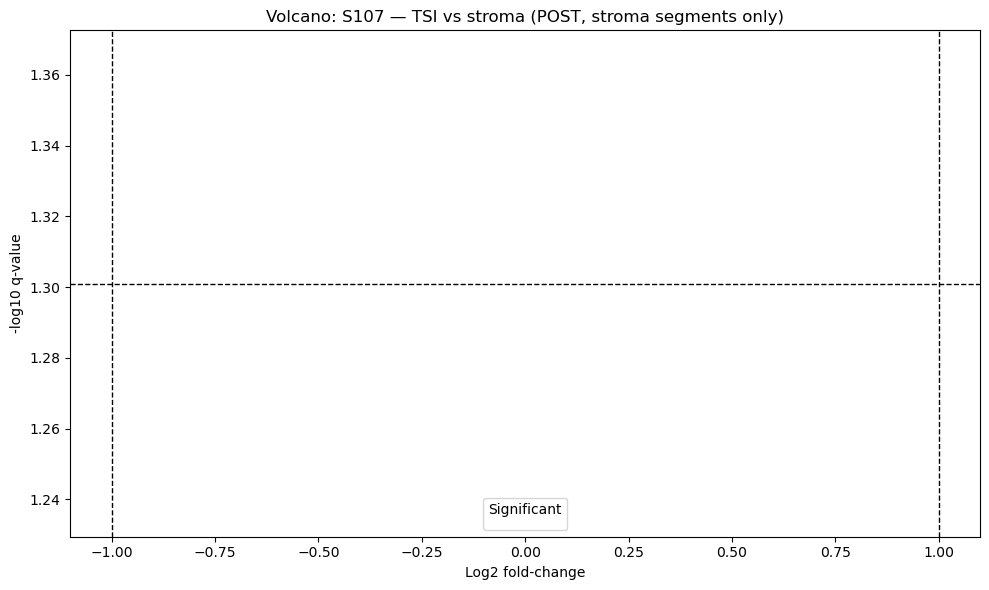

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


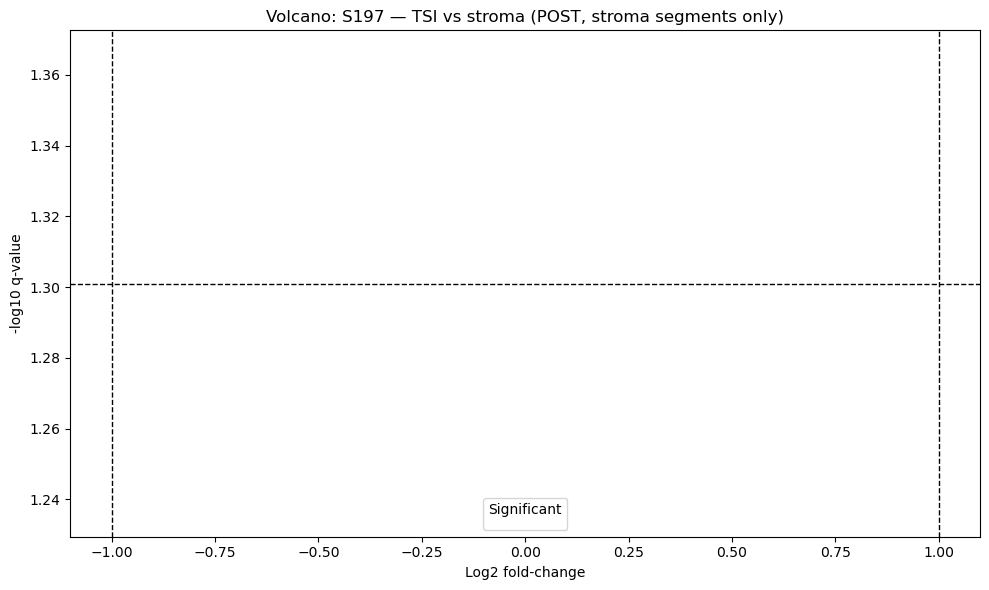

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


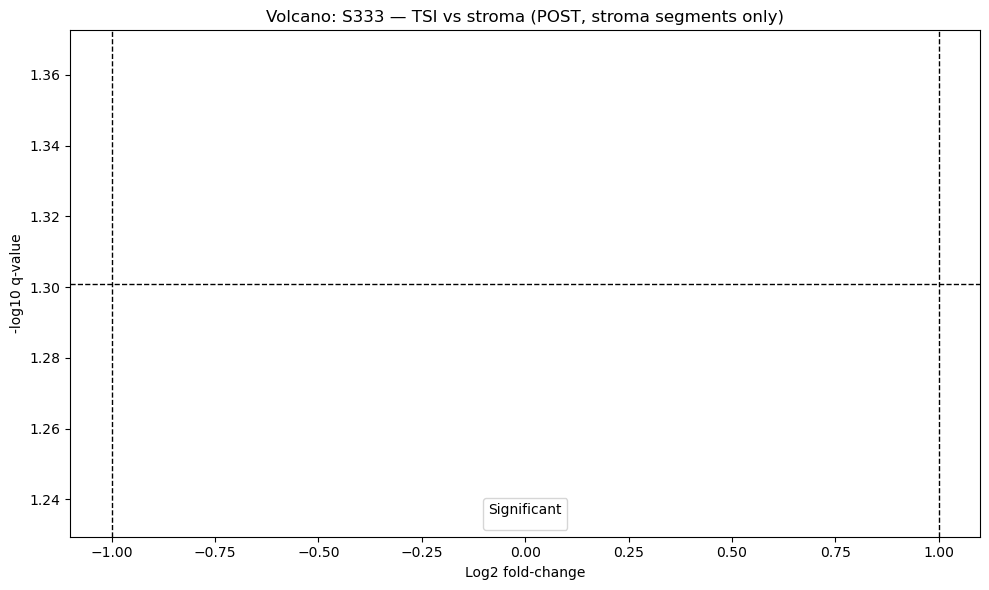

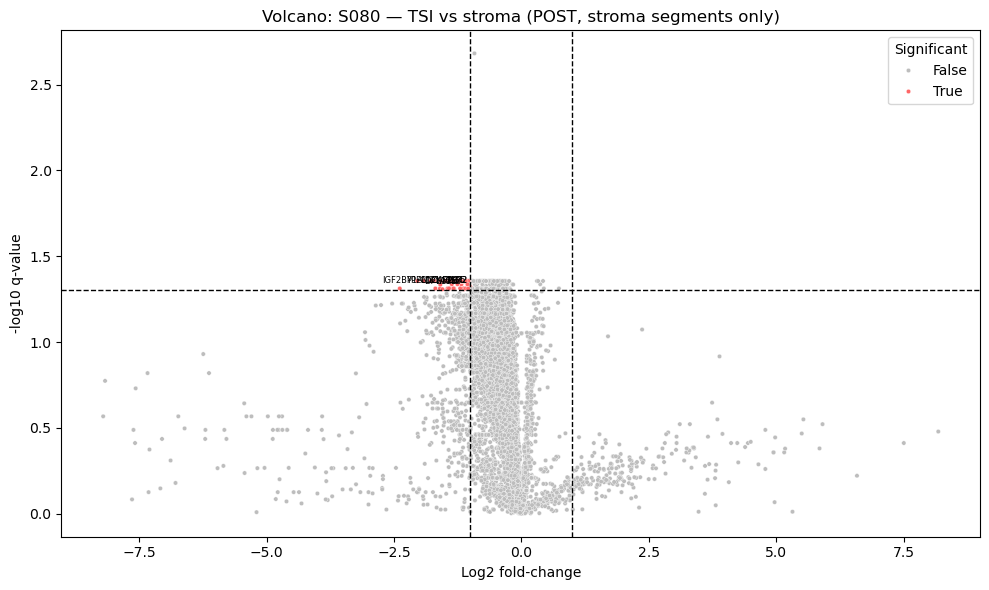

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


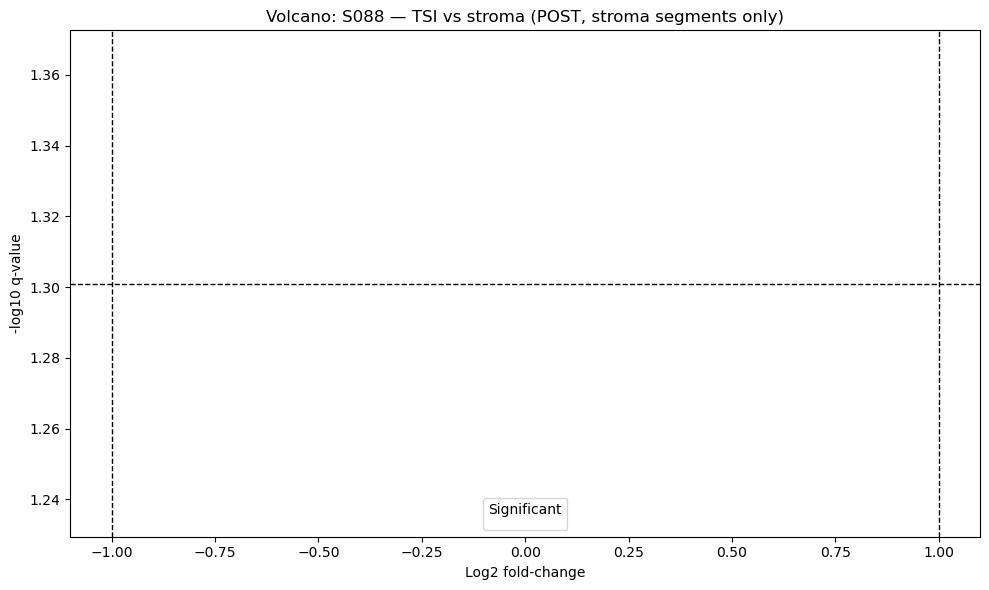

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


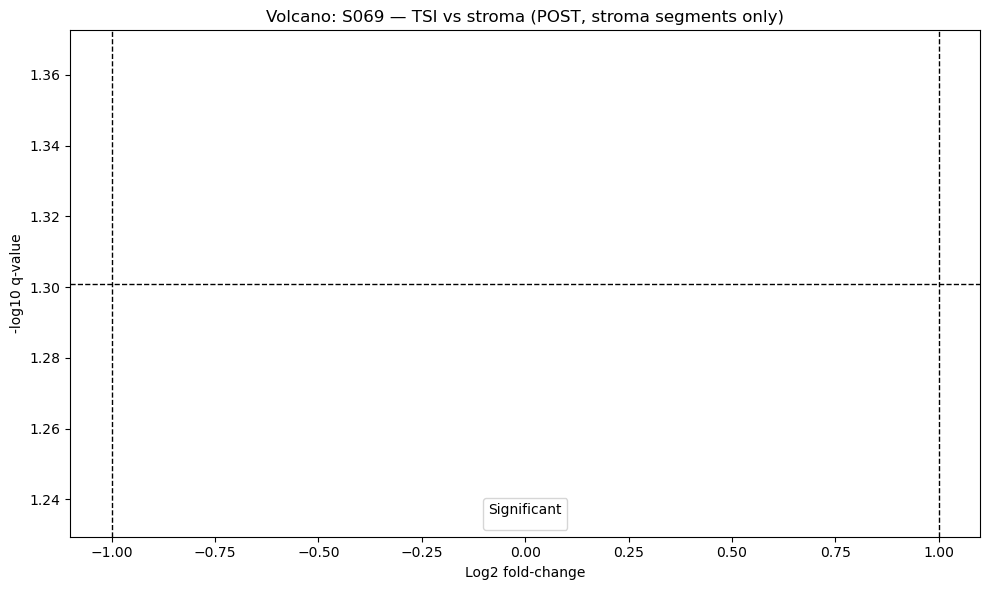

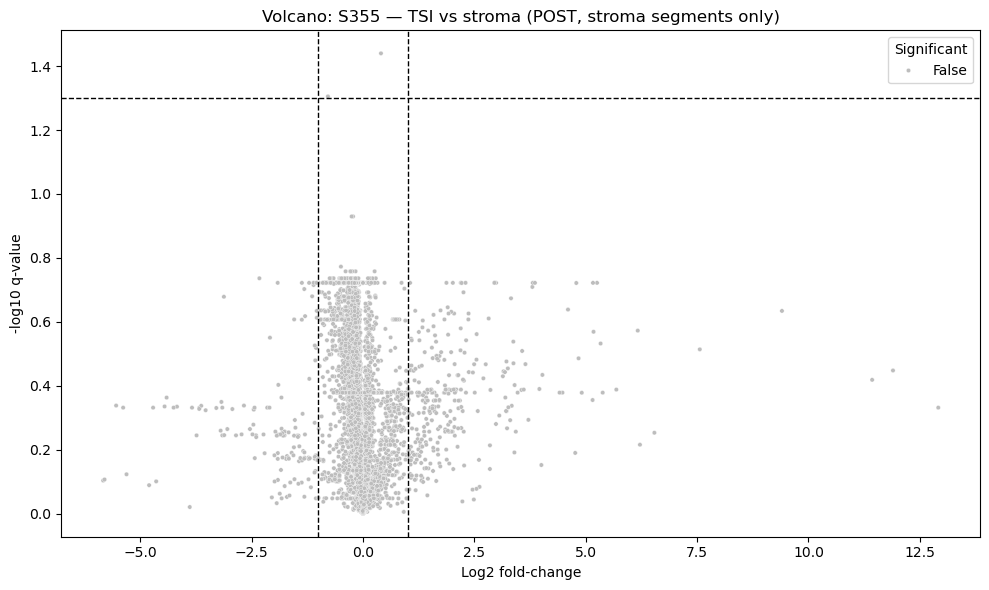

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


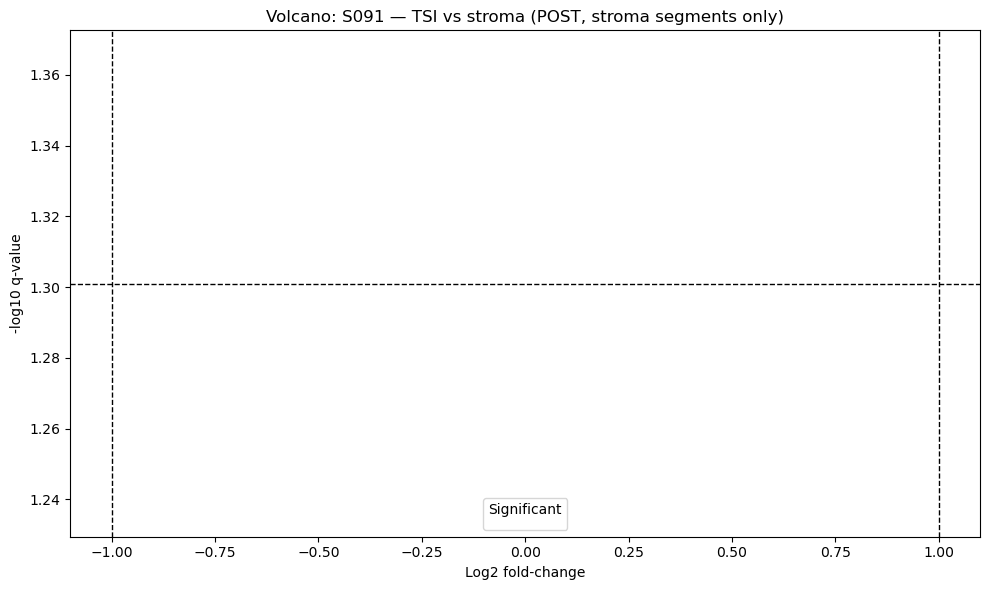

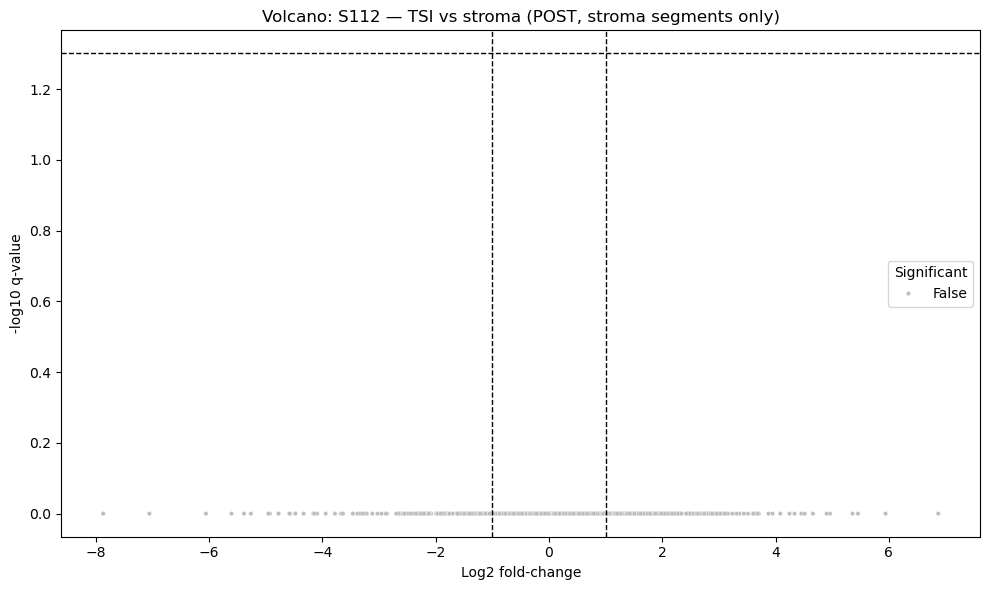

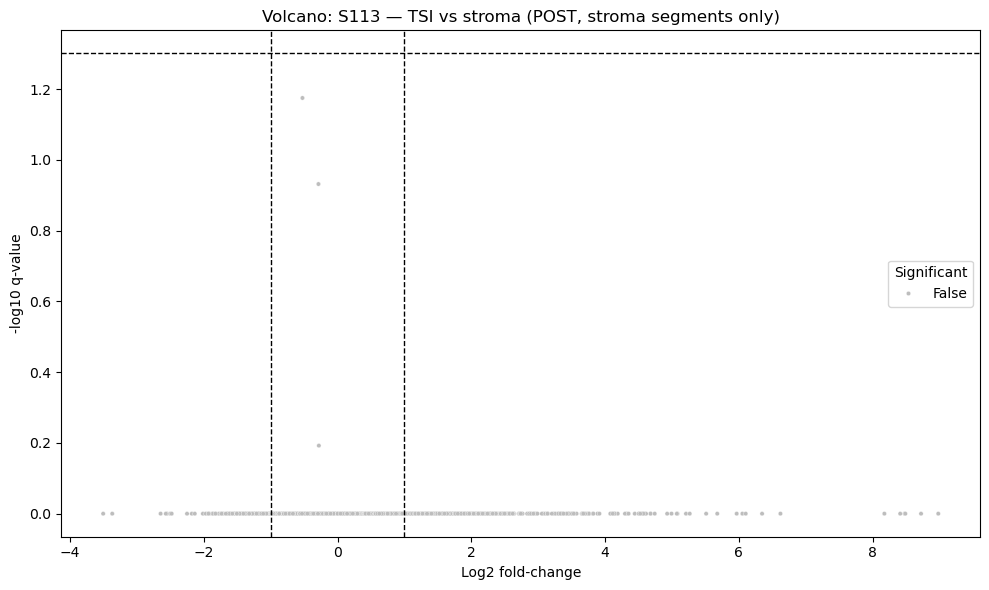

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


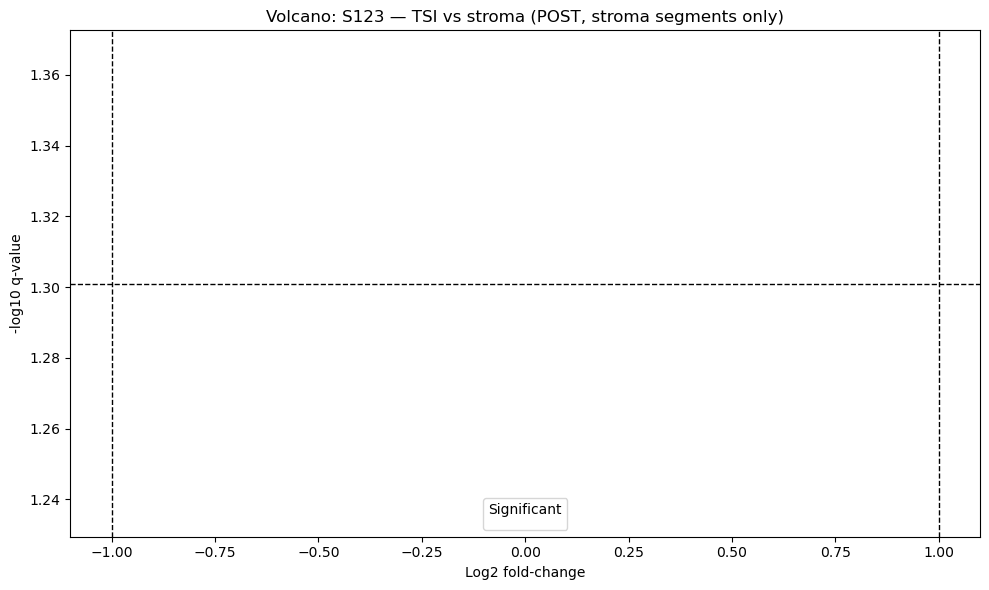

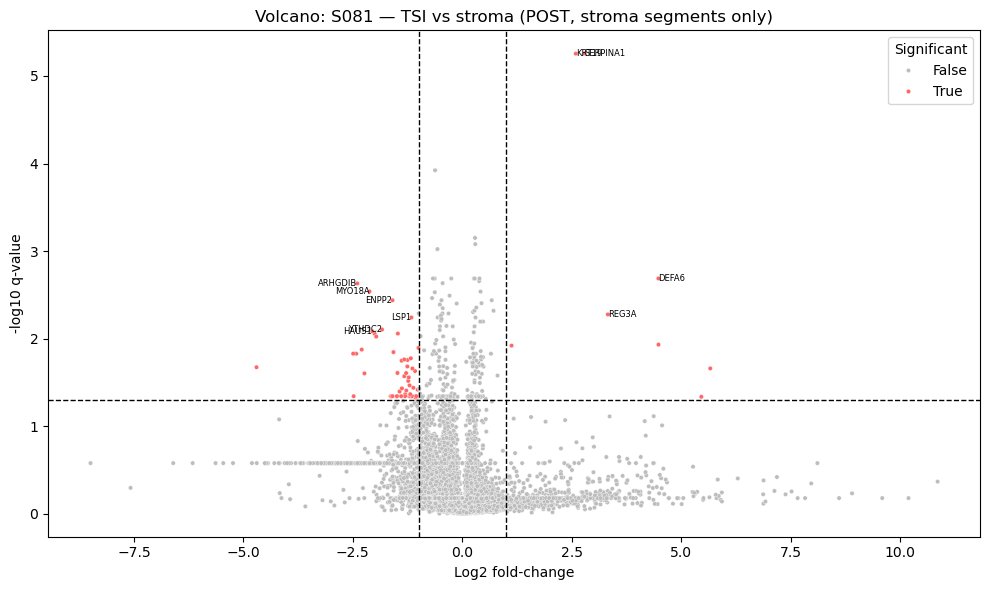

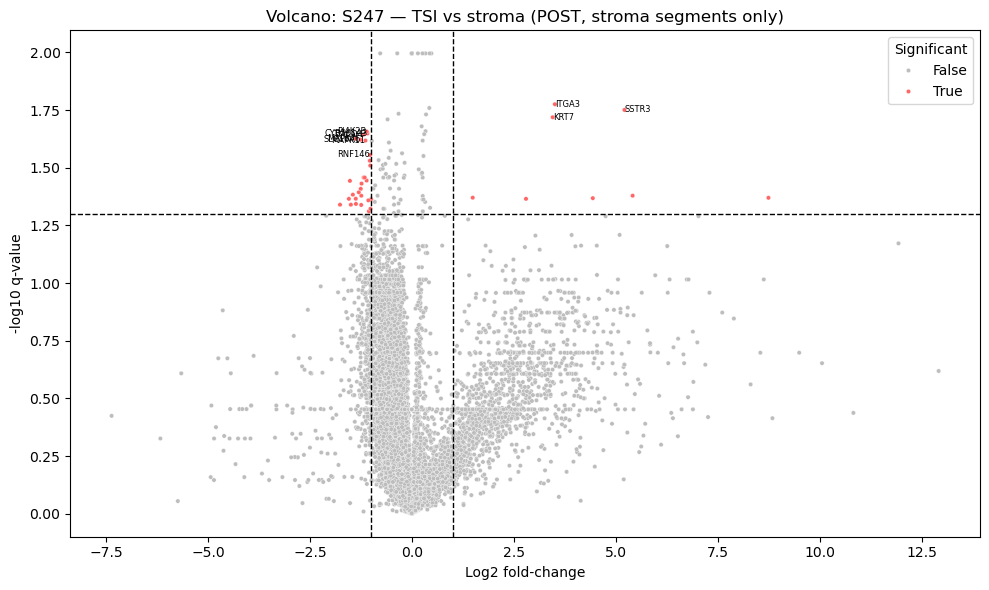

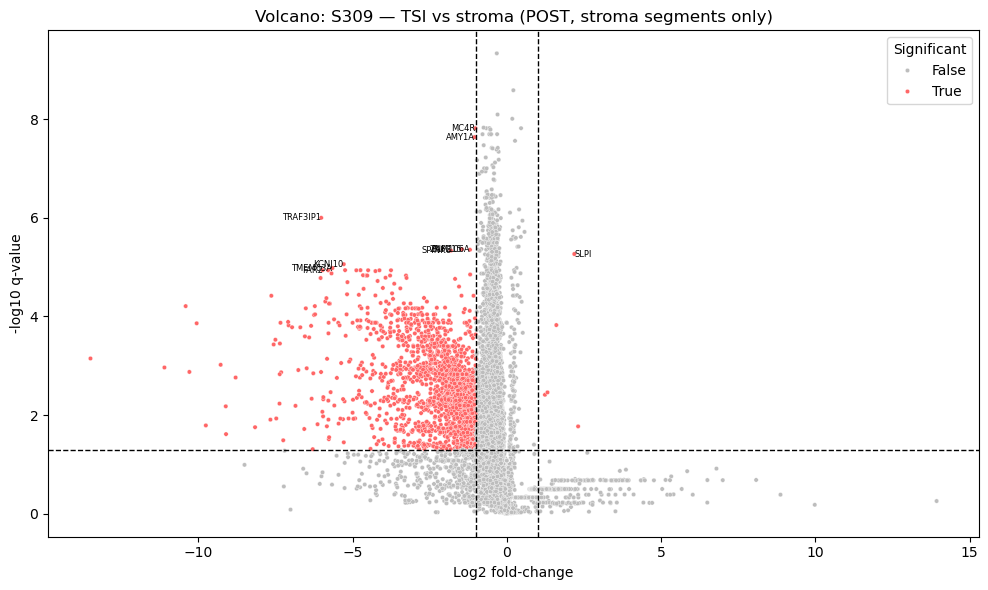

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/610203675.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


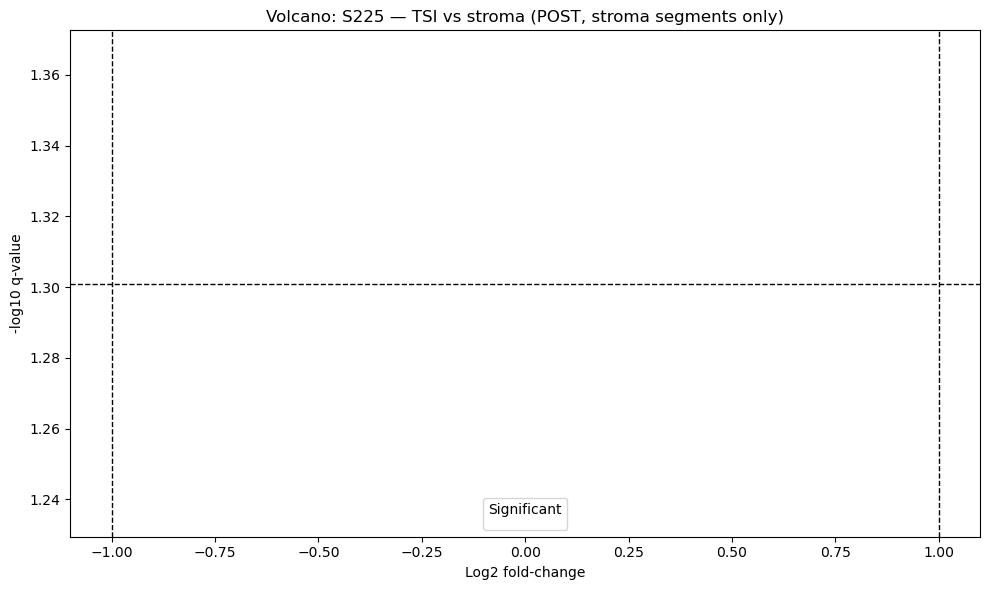

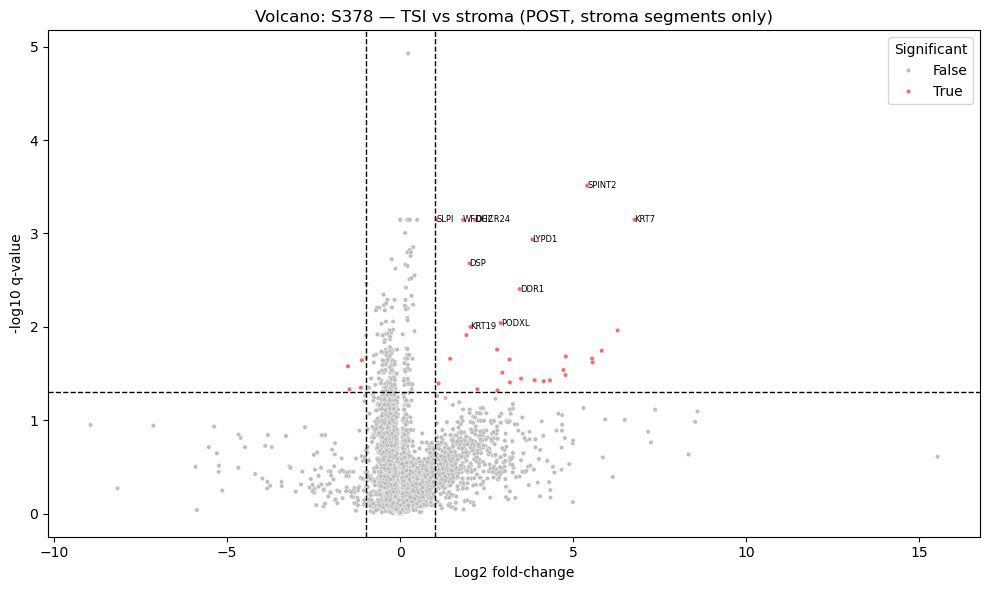

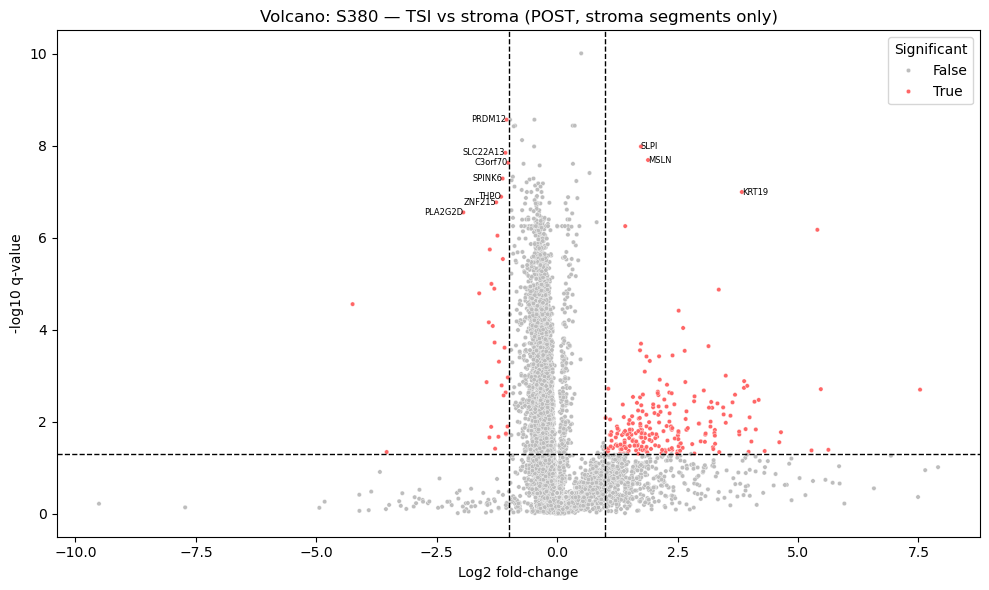

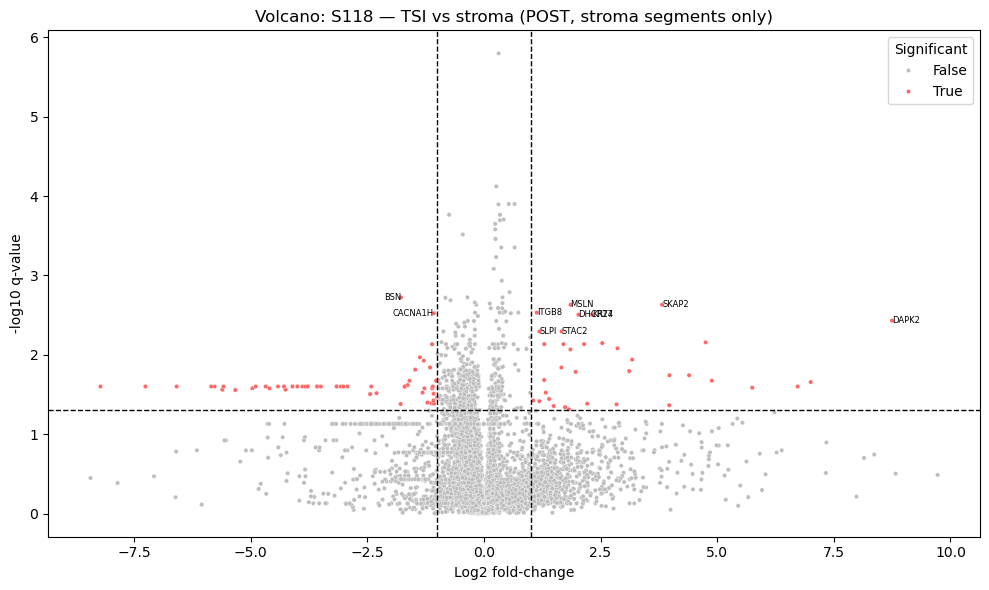

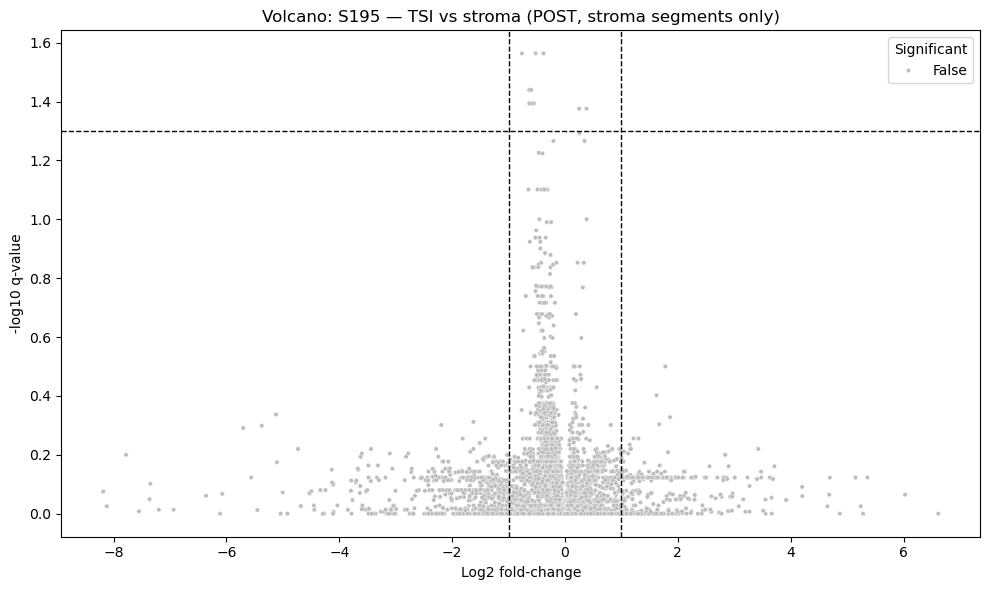

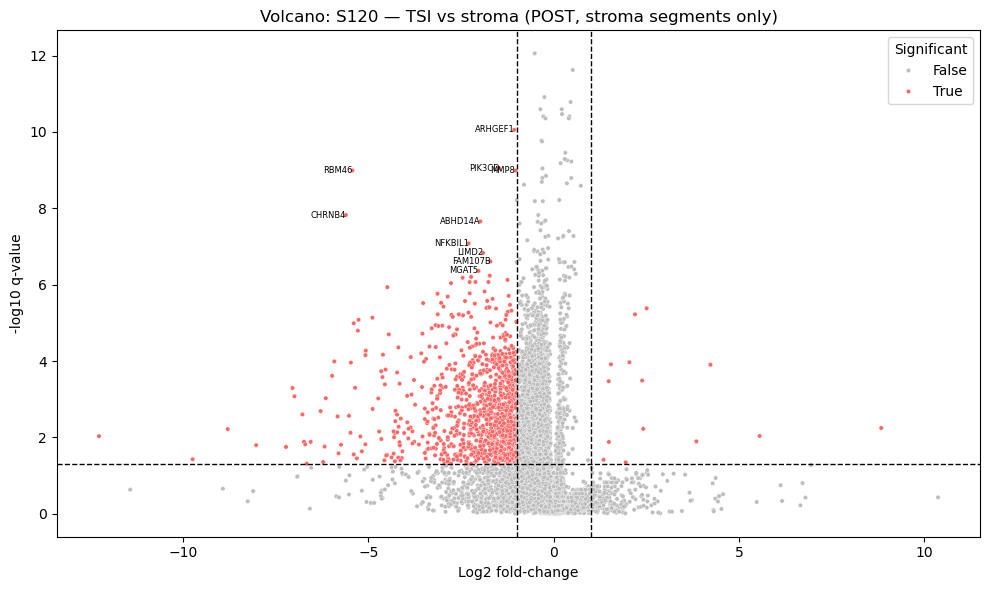

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pval_thresh = 0.05
fc_thresh = 1.0  # |Log2-FC| > 1

for patient, result_df in df_results.items():
    df_plot = result_df.reset_index().rename(columns={'index': 'gene'})

    # significance
    sig_p = df_plot['-log10_qvalue'] > -np.log10(pval_thresh)
    sig_fc = df_plot['fold-change'].abs() > fc_thresh
    df_plot['Significant'] = sig_p & sig_fc

    plt.figure(figsize=(10, 6))
    ax = sns.scatterplot(
        data=df_plot,
        x='fold-change',
        y='-log10_qvalue',
        s=10,
        hue='Significant',
        palette={True: '#FF6666', False: '#BDBDBD'}
    )

    # annotate top N significant hits (keep it readable)
    top_hits = df_plot[df_plot['Significant']].sort_values('-log10_qvalue', ascending=False).head(10)
    for _, row in top_hits.iterrows():
        ax.text(
            row['fold-change'],
            row['-log10_qvalue'],
            row['gene'],
            fontsize=6,
            ha='right' if row['fold-change'] < 0 else 'left',
            va='center'
        )

    ax.axvline(x=fc_thresh, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=-fc_thresh, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--', linewidth=1)

    ax.set_title(f'Volcano: {patient} — TSI vs stroma (POST, stroma segments only)')
    ax.set_xlabel('Log2 fold-change')
    ax.set_ylabel('-log10 q-value')
    ax.legend(title='Significant', loc='best')
    plt.tight_layout()
    plt.show()


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


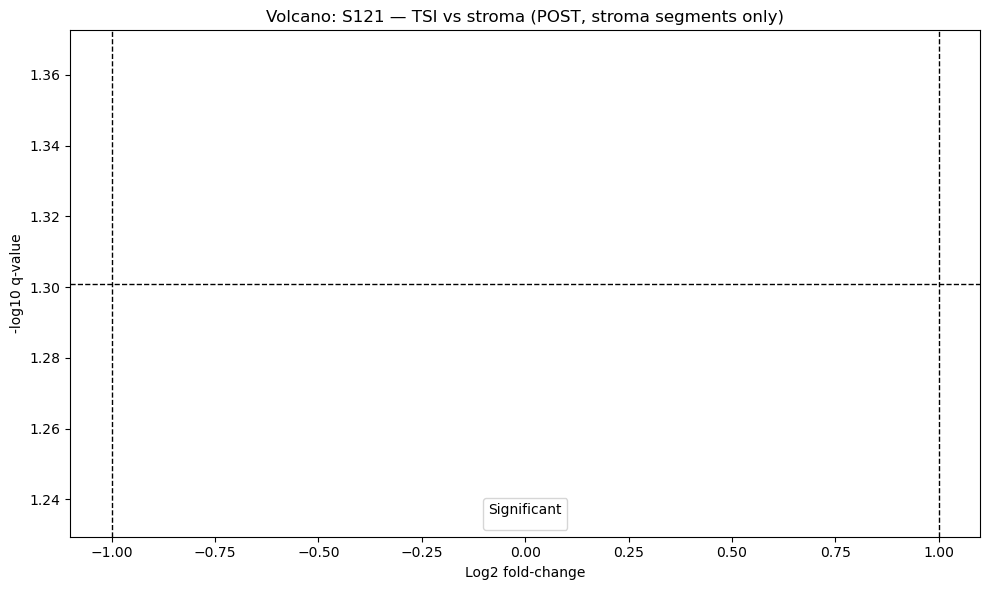

Saved 0 significant hits for patient S121


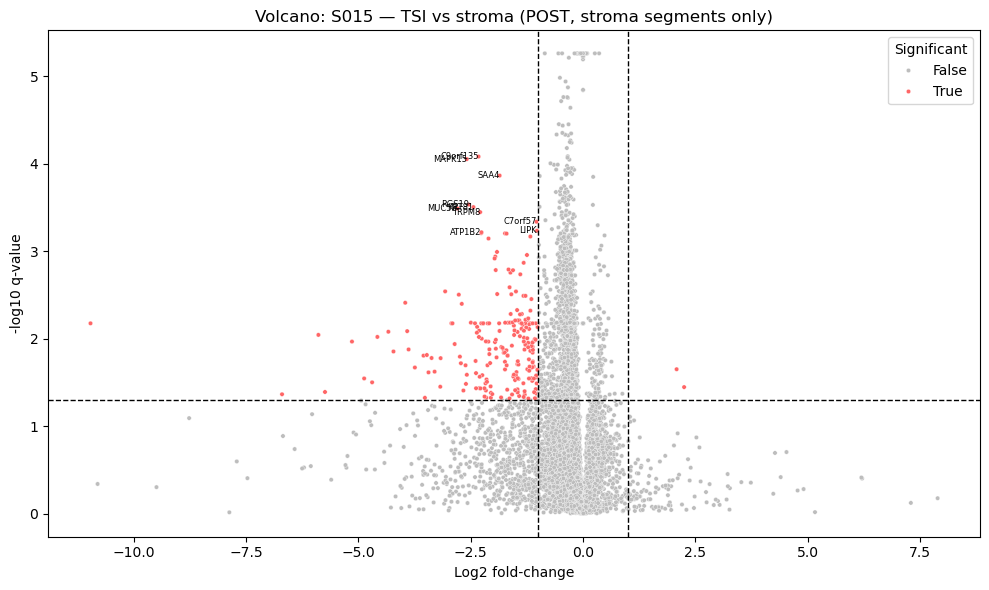

Saved 15 significant hits for patient S015


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


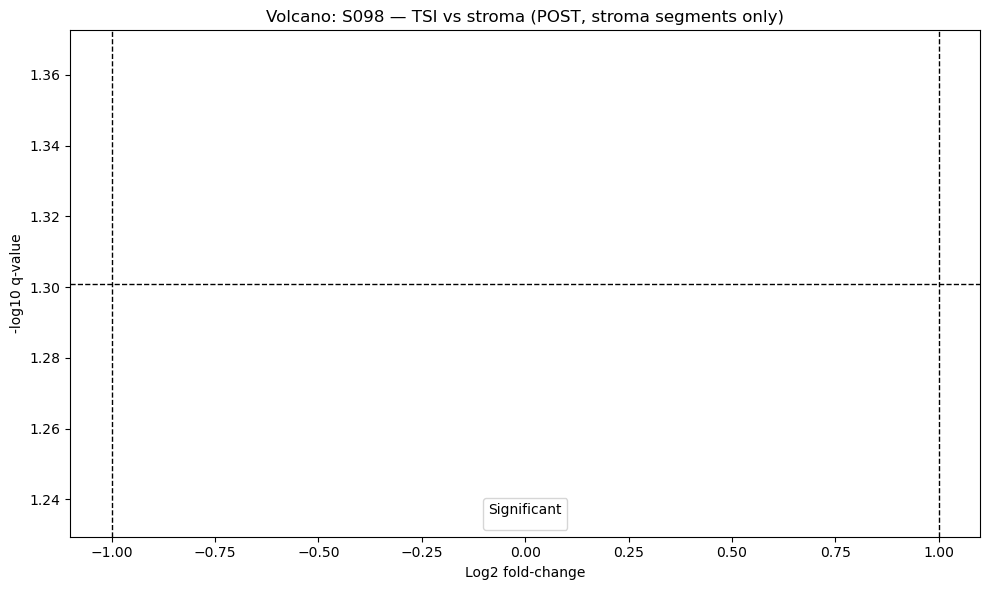

Saved 0 significant hits for patient S098


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


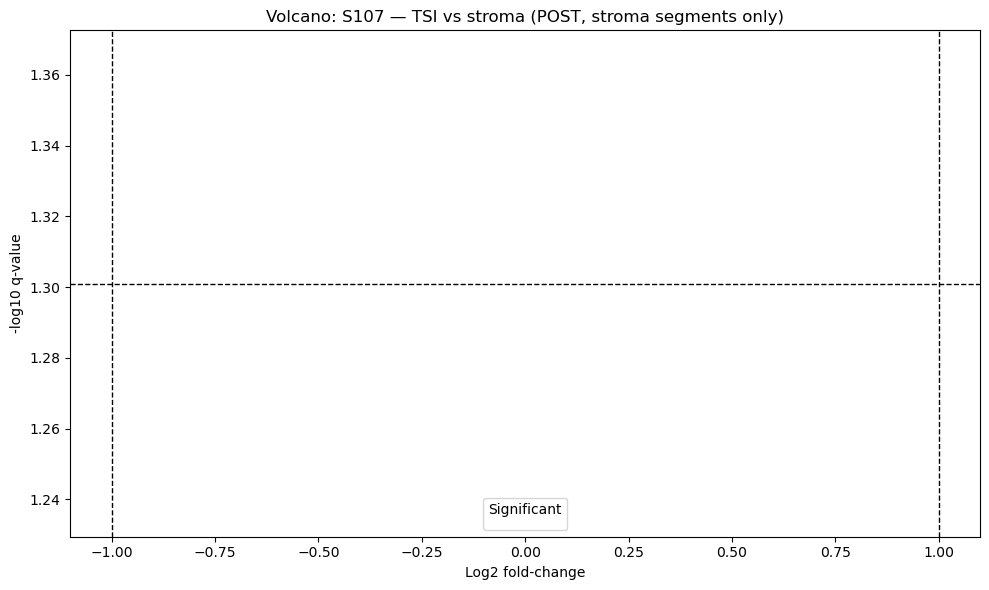

Saved 0 significant hits for patient S107


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


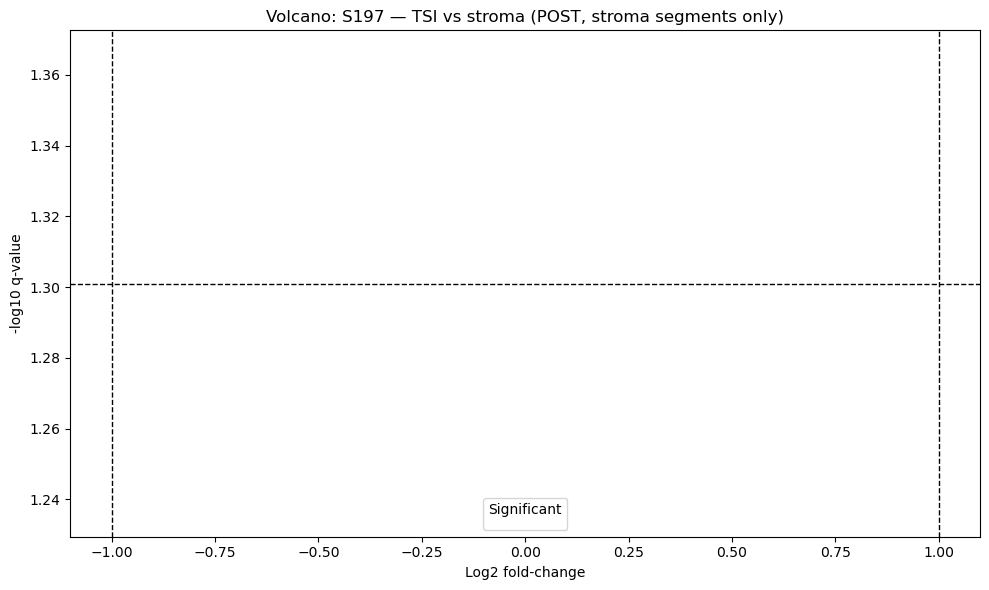

Saved 0 significant hits for patient S197


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


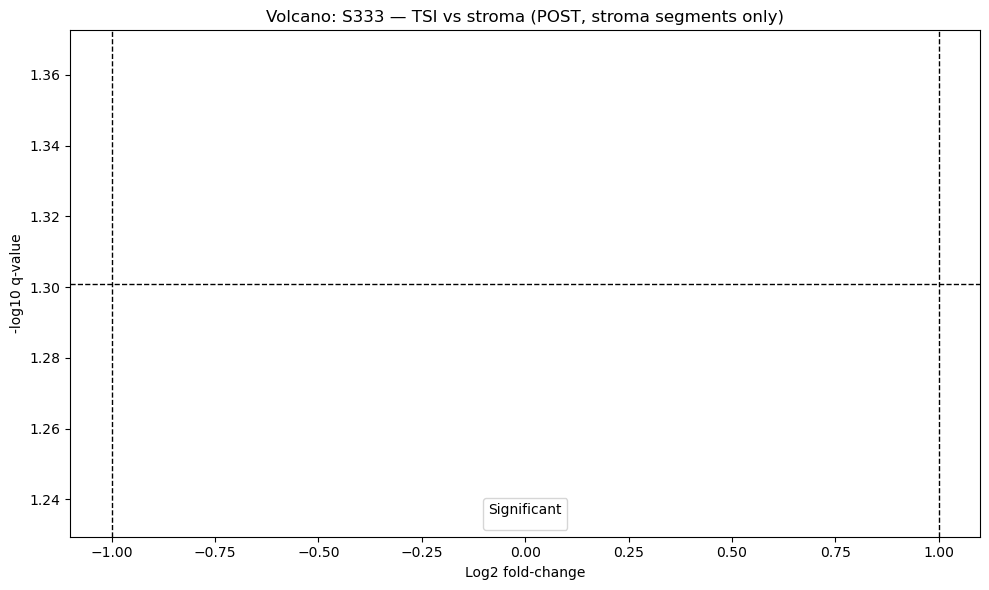

Saved 0 significant hits for patient S333


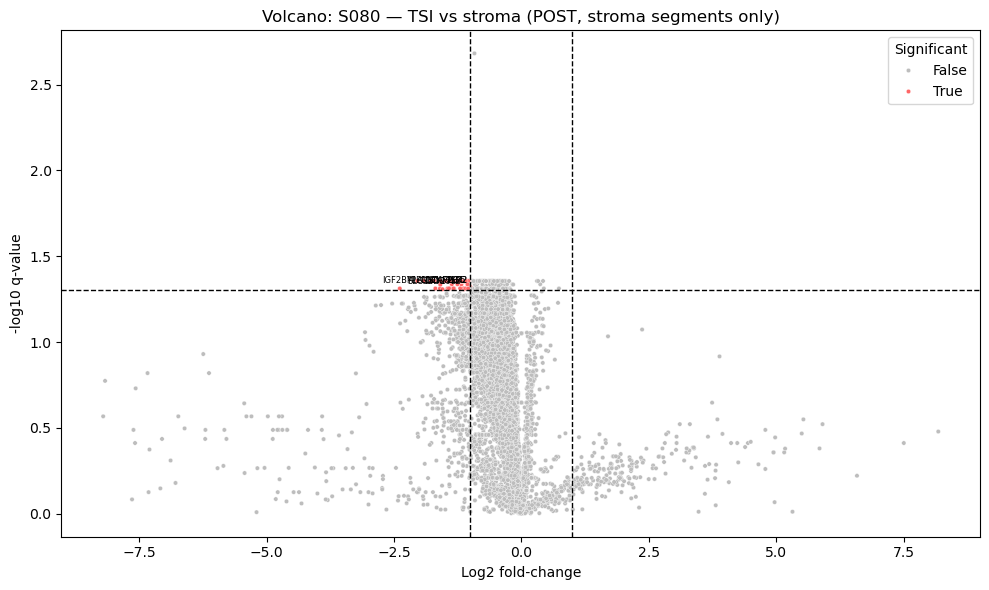

Saved 15 significant hits for patient S080


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


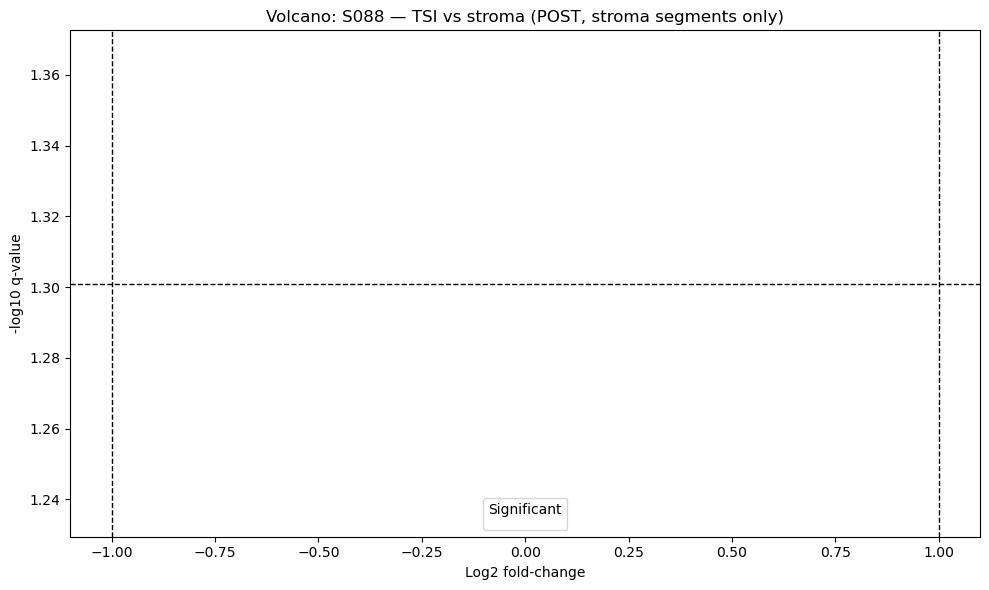

Saved 0 significant hits for patient S088


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


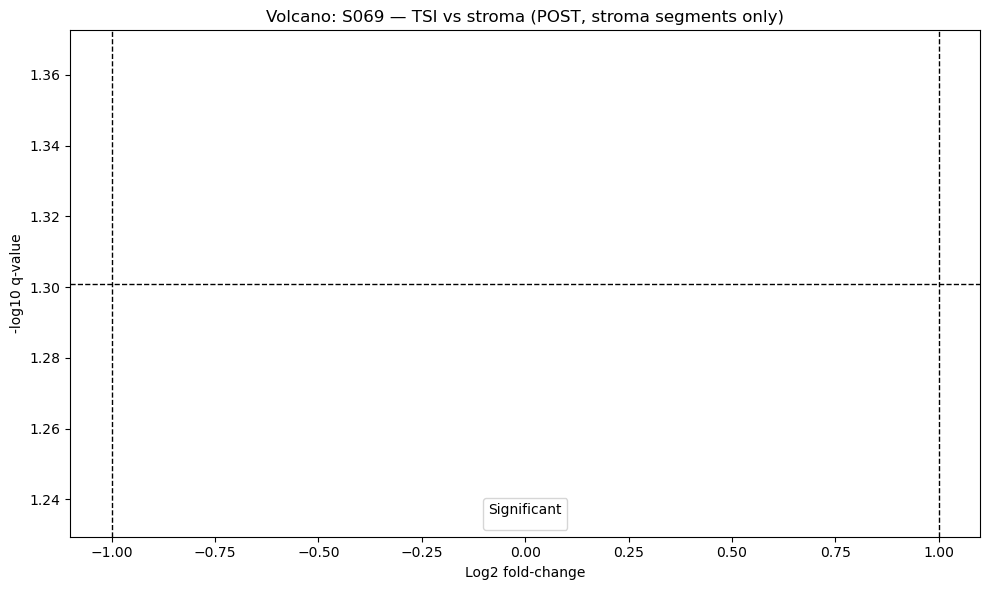

Saved 0 significant hits for patient S069


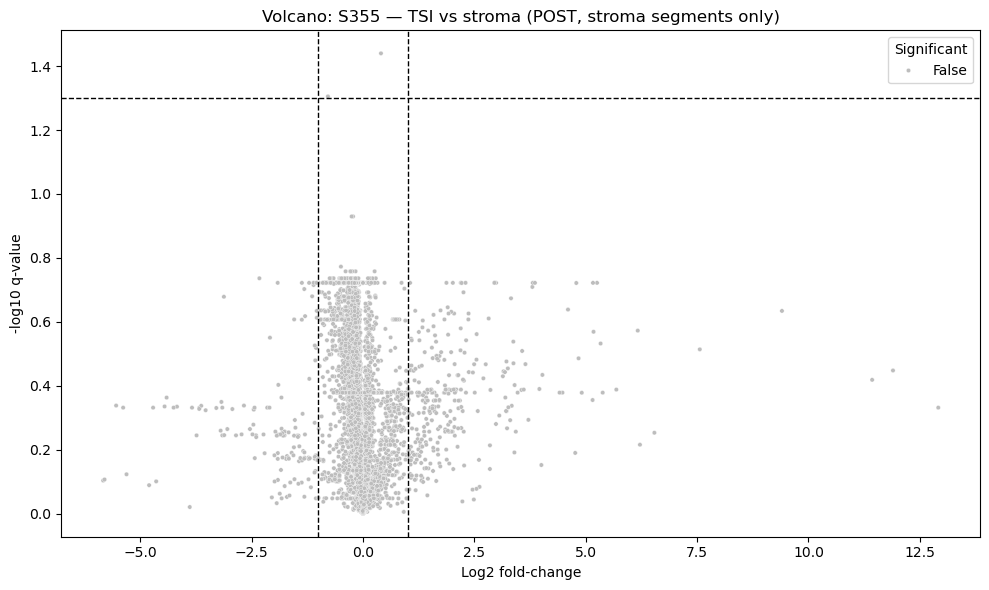

Saved 0 significant hits for patient S355


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


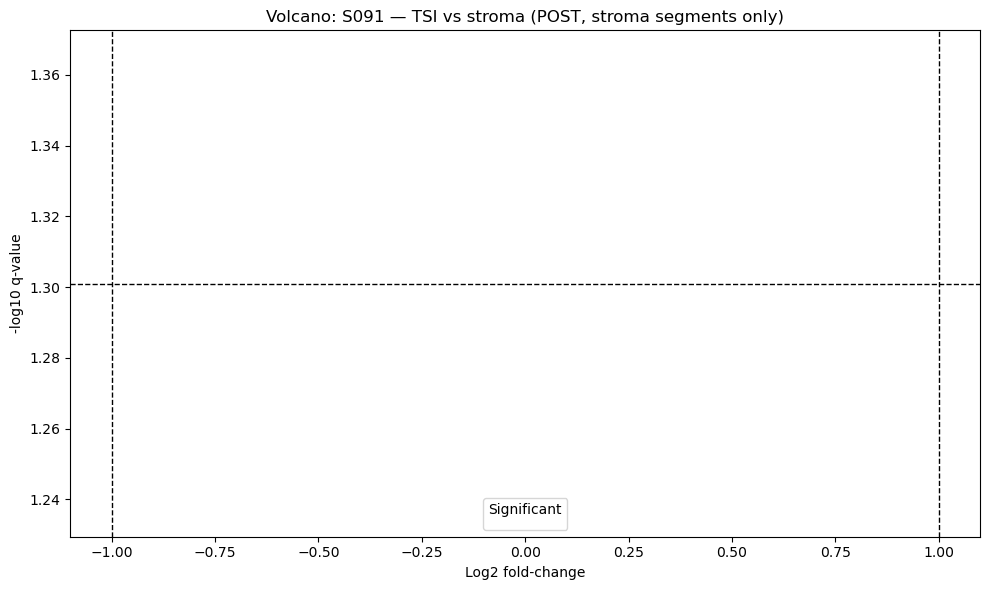

Saved 0 significant hits for patient S091


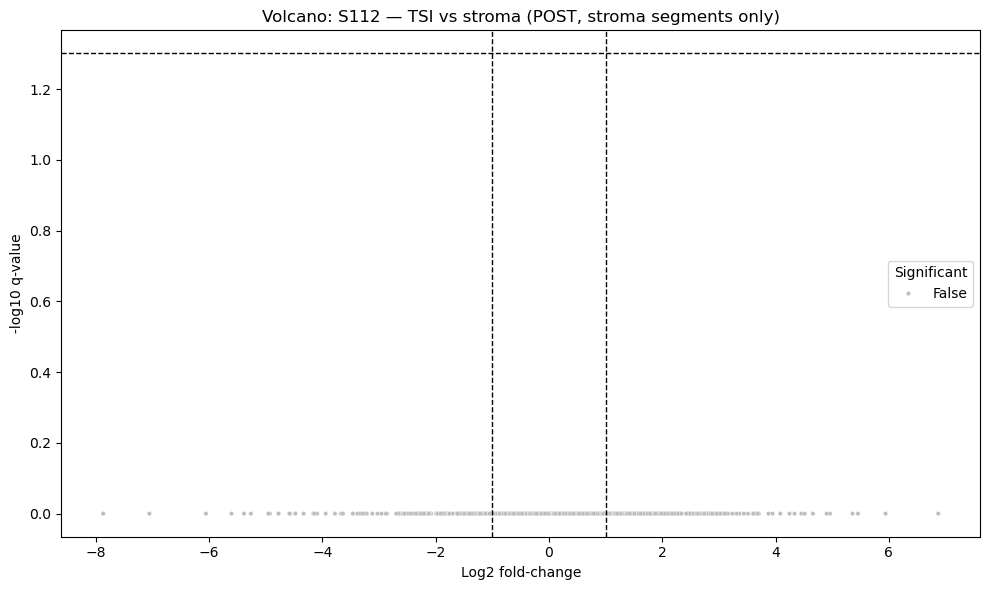

Saved 0 significant hits for patient S112


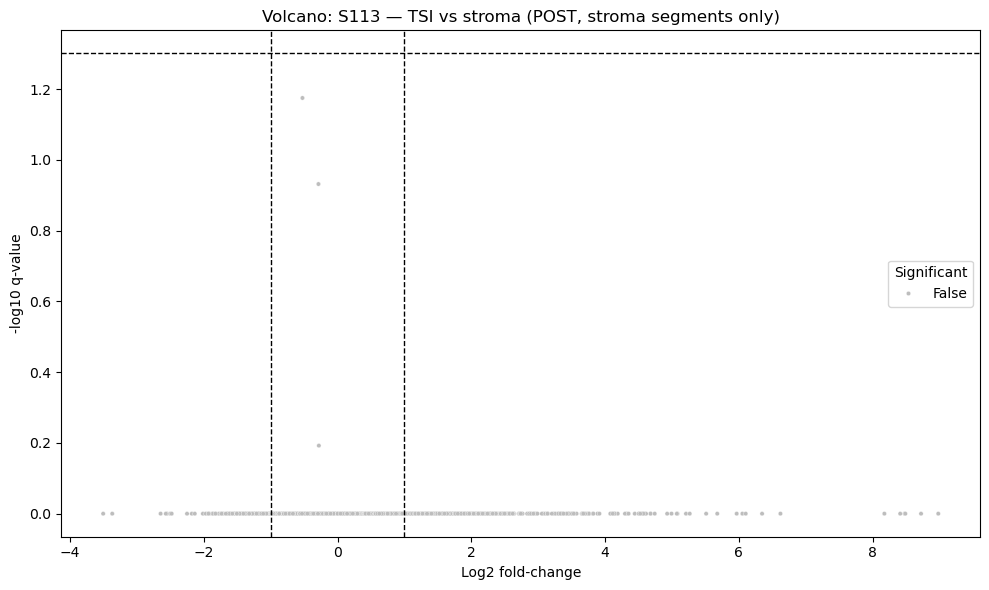

Saved 0 significant hits for patient S113


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


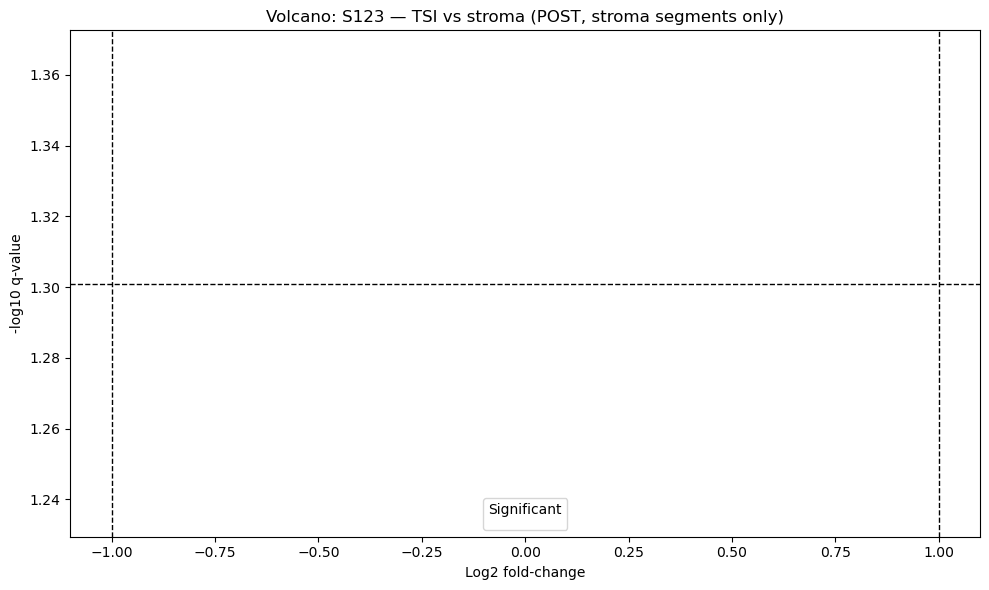

Saved 0 significant hits for patient S123


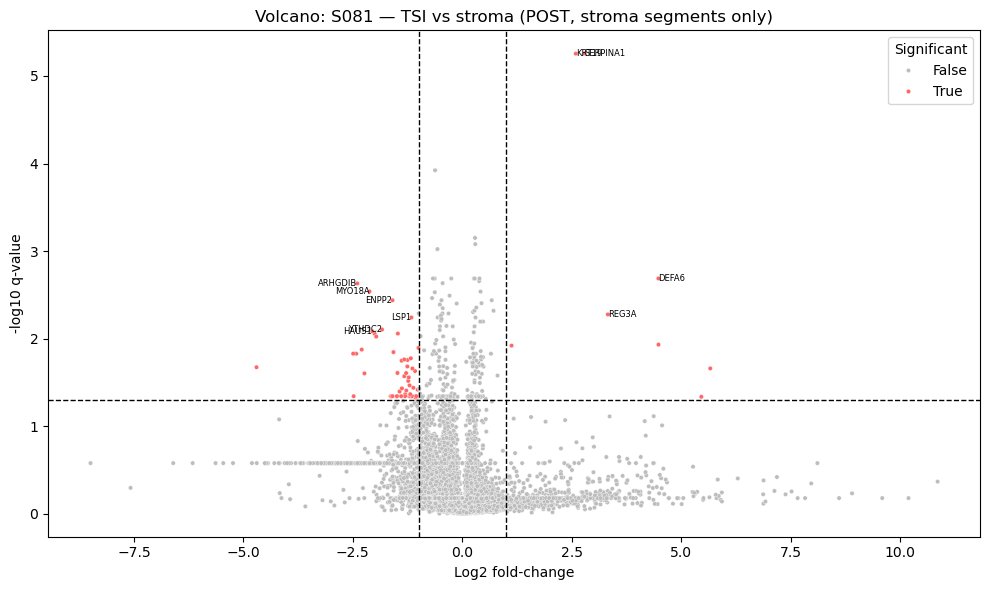

Saved 15 significant hits for patient S081


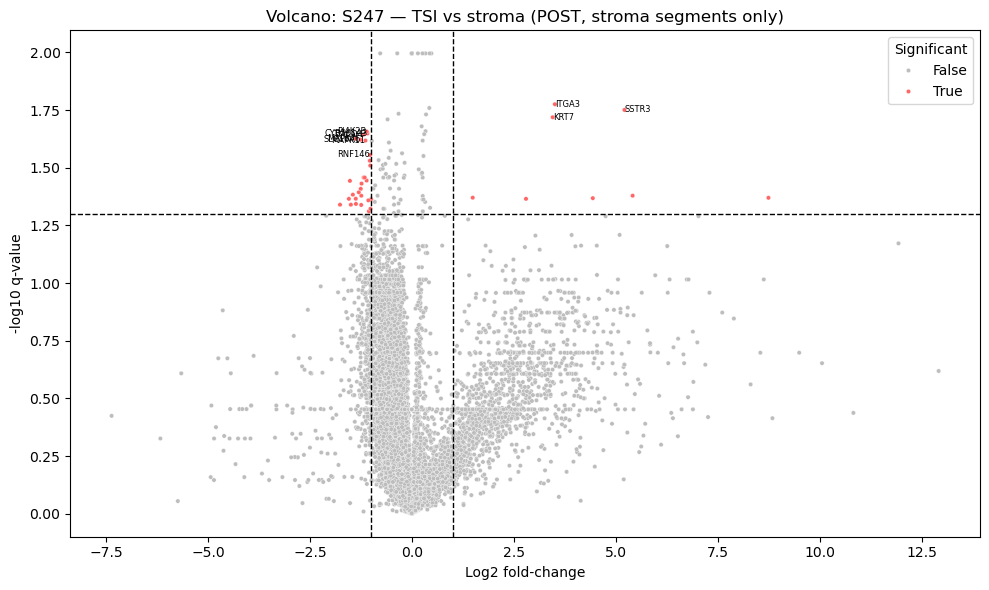

Saved 15 significant hits for patient S247


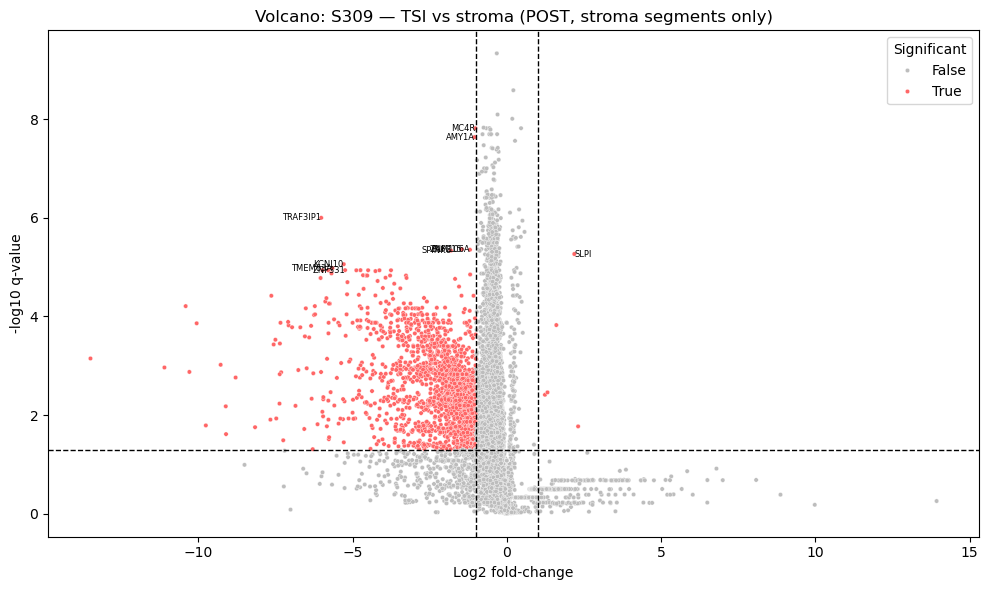

Saved 15 significant hits for patient S309


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_3165/2507059201.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Significant', loc='best')


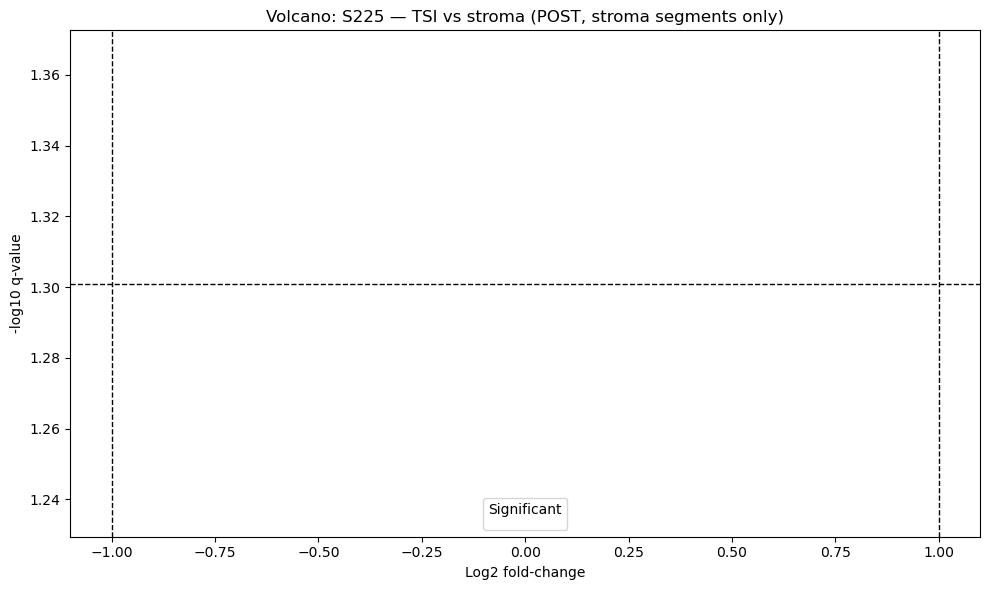

Saved 0 significant hits for patient S225


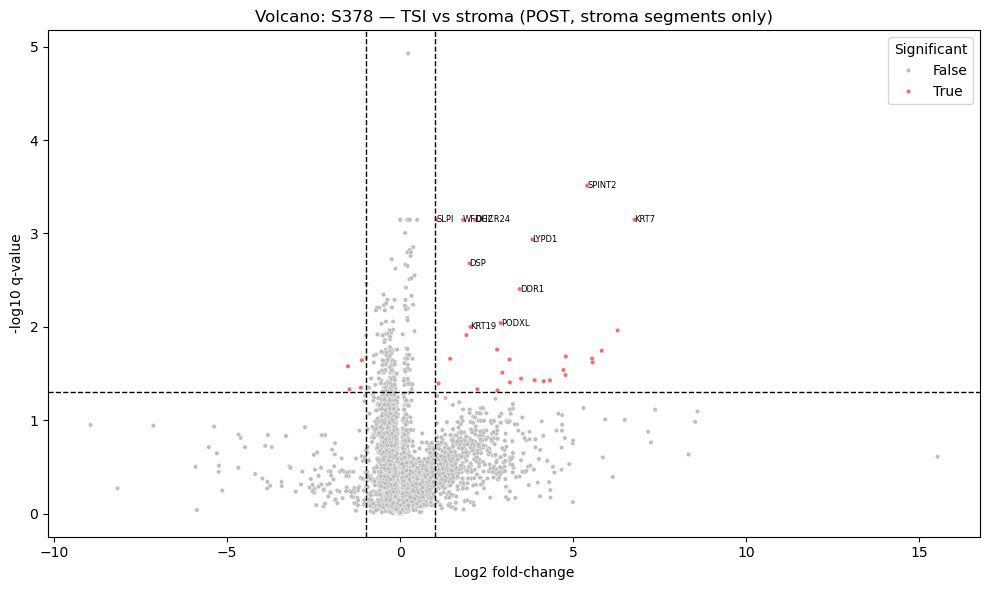

Saved 15 significant hits for patient S378


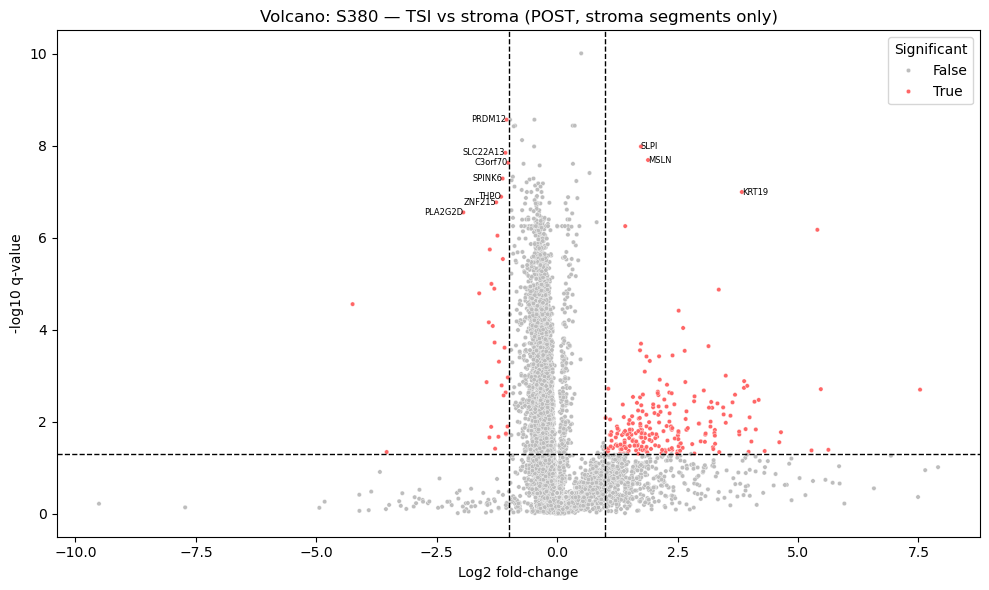

Saved 15 significant hits for patient S380


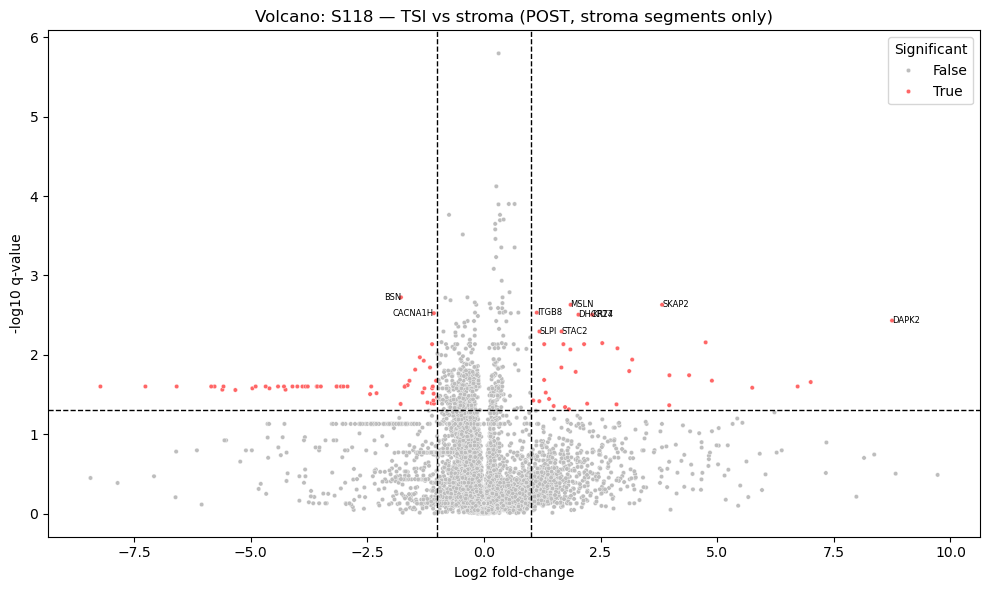

Saved 15 significant hits for patient S118


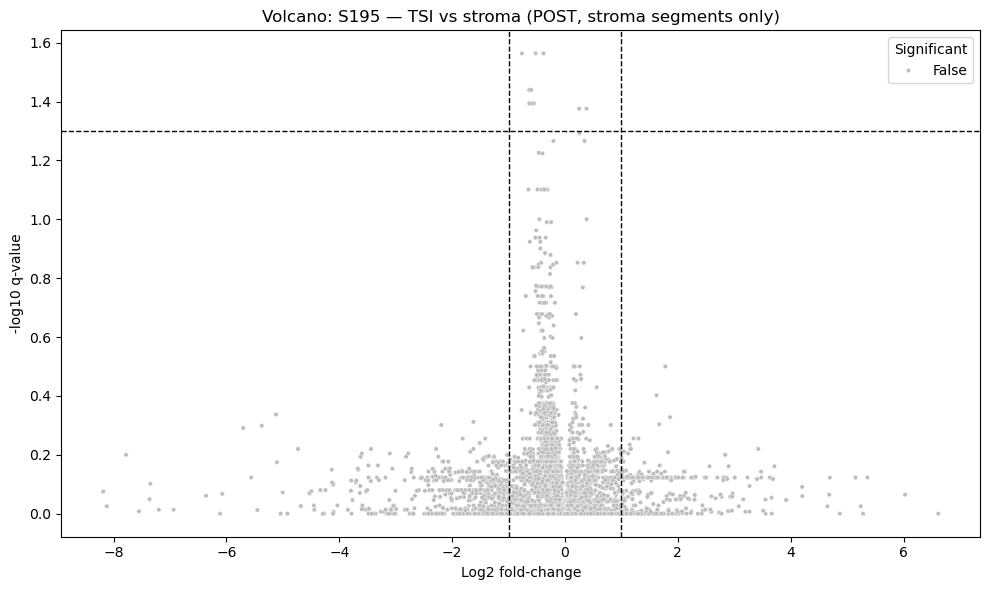

Saved 0 significant hits for patient S195


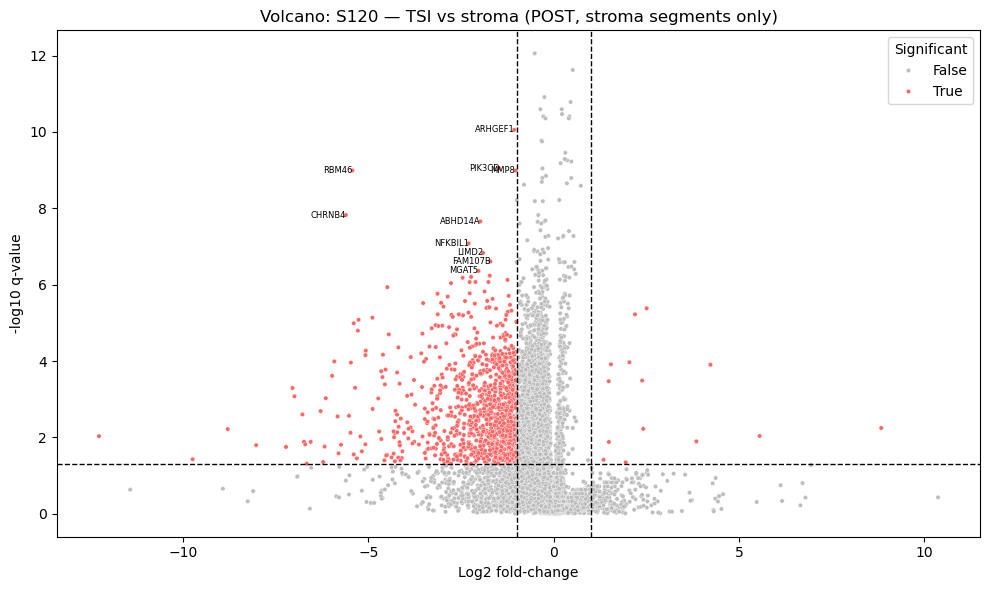

Saved 15 significant hits for patient S120


In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
pval_thresh = 0.05
fc_thresh = 1.0  # |Log2-FC| > 1
top_n = 10  # for labeling in plot
output_folder = "/Users/nikamikhailava/Desktop/batch_merged_new/top_hits_TSI_stroma_separate_patients/"
os.makedirs(output_folder, exist_ok=True)

for patient, result_df in df_results.items():
    df_plot = result_df.reset_index().rename(columns={'index': 'gene'})

    # Significance criteria
    sig_p = df_plot['-log10_qvalue'] > -np.log10(pval_thresh)
    sig_fc = df_plot['fold-change'].abs() > fc_thresh
    df_plot['Significant'] = sig_p & sig_fc

    # Save significant hits to CSV
    sig_hits = (
    df_plot[df_plot['Significant']]
    .sort_values('q-value', ascending=True)
    .head(15)
)
    sig_hits.to_csv(os.path.join(output_folder, f"{patient}_significant_hits.csv"), index=False)

    # Volcano plot
    plt.figure(figsize=(10, 6))
    ax = sns.scatterplot(
        data=df_plot,
        x='fold-change',
        y='-log10_qvalue',
        s=10,
        hue='Significant',
        palette={True: '#FF6666', False: '#BDBDBD'}
    )

    # Annotate top N significant hits
    top_hits = sig_hits.head(top_n)
    for _, row in top_hits.iterrows():
        ax.text(
            row['fold-change'],
            row['-log10_qvalue'],
            row['gene'],
            fontsize=6,
            ha='right' if row['fold-change'] < 0 else 'left',
            va='center'
        )

    # Threshold lines
    ax.axvline(x=fc_thresh, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=-fc_thresh, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--', linewidth=1)

    ax.set_title(f'Volcano: {patient} — TSI vs stroma (POST, stroma segments only)')
    ax.set_xlabel('Log2 fold-change')
    ax.set_ylabel('-log10 q-value')
    ax.legend(title='Significant', loc='best')
    plt.tight_layout()
    plt.show()

    print(f"Saved {len(sig_hits)} significant hits for patient {patient}")


In [37]:
import os, glob
import pandas as pd
from itertools import combinations

output_folder = "/Users/nikamikhailava/Desktop/batch_merged_new/top_hits_TSI_stroma_separate_patients/"

# 1) Read all CSVs and collect gene sets per patient
csv_files = sorted(glob.glob(os.path.join(output_folder, "*_significant_hits.csv")))
patient_to_genes = {}

for f in csv_files:
    # Derive patient name from filename: "<PATIENT>_significant_hits.csv"
    patient = os.path.basename(f).replace("_significant_hits.csv", "")
    df = pd.read_csv(f)
    if "gene" not in df.columns:
        raise ValueError(f"'gene' column not found in {f}")
    genes = set(df["gene"].dropna().astype(str))
    patient_to_genes[patient] = genes

# 2) Intersection across ALL patients
if patient_to_genes:
    genes_in_all = set.intersection(*patient_to_genes.values()) if len(patient_to_genes) > 1 else next(iter(patient_to_genes.values()))
else:
    genes_in_all = set()

print(f"Genes appearing in ALL patients ({len(genes_in_all)}):")
print(sorted(genes_in_all))

# Optional: save this list
pd.Series(sorted(genes_in_all), name="gene").to_csv(os.path.join(output_folder, "genes_in_all_patients.csv"), index=False)

# 3) Pairwise intersections
pairwise_rows = []
for (p1, p2) in combinations(patient_to_genes.keys(), 2):
    inter = patient_to_genes[p1] & patient_to_genes[p2]
    pairwise_rows.append({"patient1": p1, "patient2": p2, "n_intersection": len(inter)})
pairwise_df = pd.DataFrame(pairwise_rows).sort_values("n_intersection", ascending=False)
pairwise_df.to_csv(os.path.join(output_folder, "pairwise_intersections_summary.csv"), index=False)

# 4) Presence matrix (patients × genes) + counts
all_genes = sorted(set().union(*patient_to_genes.values())) if patient_to_genes else []
presence = pd.DataFrame(False, index=all_genes, columns=sorted(patient_to_genes.keys()))
for p, genes in patient_to_genes.items():
    presence.loc[list(genes), p] = True

presence["n_patients"] = presence.sum(axis=1)
presence.to_csv(os.path.join(output_folder, "gene_presence_matrix.csv"))

# 5) Genes present in at least k patients (tweak k as needed)
k = 2
genes_atleast_k = presence.index[presence["n_patients"] >= k].tolist()
pd.Series(genes_atleast_k, name=f"genes_in_≥{k}_patients").to_csv(
    os.path.join(output_folder, f"genes_in_atleast_{k}_patients.csv"),
    index=False
)

print(f"Saved:\n- genes_in_all_patients.csv\n- pairwise_intersections_summary.csv\n- gene_presence_matrix.csv\n- genes_in_atleast_{k}_patients.csv")


Genes appearing in ALL patients (0):
[]
Saved:
- genes_in_all_patients.csv
- pairwise_intersections_summary.csv
- gene_presence_matrix.csv
- genes_in_atleast_2_patients.csv


In [38]:
import os, glob
import pandas as pd
from itertools import combinations

output_folder = "/Users/nikamikhailava/Desktop/batch_merged_new/top_hits_TSI_stroma_separate_patients/"

# 1) Read all CSVs and store fold-change per patient
csv_files = sorted(glob.glob(os.path.join(output_folder, "*_significant_hits.csv")))
patient_dfs = []

for f in csv_files:
    patient = os.path.basename(f).replace("_significant_hits.csv", "")
    df = pd.read_csv(f)
    if "gene" not in df.columns or "fold-change" not in df.columns:
        raise ValueError(f"Required columns not found in {f}")
    df = df[["gene", "fold-change"]].copy()
    df.rename(columns={"fold-change": patient}, inplace=True)
    patient_dfs.append(df)

# Merge into one big table: gene × patients with fold-change values
fc_matrix = patient_dfs[0]
for df in patient_dfs[1:]:
    fc_matrix = pd.merge(fc_matrix, df, on="gene", how="outer")

# 2) Save the fold-change matrix
fc_matrix.to_csv(os.path.join(output_folder, "fold_change_matrix.csv"), index=False)

# 3) Intersection across ALL patients
patients = [os.path.basename(f).replace("_significant_hits.csv", "") for f in csv_files]
genes_in_all = fc_matrix.dropna(subset=patients, how="any")["gene"].tolist()
pd.Series(genes_in_all, name="gene").to_csv(
    os.path.join(output_folder, "genes_in_all_patients.csv"), index=False
)

# 4) Presence counts (how many patients a gene appears in)
presence_counts = fc_matrix.set_index("gene")[patients].notna().sum(axis=1)
presence_counts = presence_counts.reset_index().rename(columns={0: "n_patients"})
presence_counts.to_csv(os.path.join(output_folder, "gene_presence_counts.csv"), index=False)

print("Saved:")
print("- fold_change_matrix.csv (fold changes per gene per patient)")
print("- genes_in_all_patients.csv (intersection list)")
print("- gene_presence_counts.csv (how many patients each gene appears in)")


Saved:
- fold_change_matrix.csv (fold changes per gene per patient)
- genes_in_all_patients.csv (intersection list)
- gene_presence_counts.csv (how many patients each gene appears in)
